<a href="https://colab.research.google.com/github/Nassiraftin/Data-analysis-trainings/blob/main/Updated_Project_Dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Installing libraries
# ─────────────────────────────────────────────────────────────────────

# Install any missing packages
!pip install imbalanced-learn openpyxl --quiet

import warnings, os
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.model_selection  import (train_test_split, GridSearchCV,
                                       StratifiedKFold, cross_val_score,
                                       learning_curve)
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score, roc_curve,
                                       confusion_matrix, classification_report,
                                       ConfusionMatrixDisplay)
from sklearn.decomposition    import PCA
from sklearn.cluster          import KMeans
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics          import silhouette_score, davies_bouldin_score
from imblearn.over_sampling   import SMOTE
import joblib

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Colour theme ──────────────────────────────────────────────────────
RED   = "#E50914"   # Netflix red
DARK  = "#221F1F"   # Netflix dark
GOLD  = "#F5A623"
BLUE  = "#4A90D9"
GREEN = "#27AE60"
GREY  = "#7F8C8D"
PAL   = [RED, DARK, GOLD, BLUE, GREEN, GREY]

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "figure.figsize": (11, 5)})

print("✅  All libraries loaded.")
print(f"   pandas {pd.__version__}  |  numpy {np.__version__}")

✅  All libraries loaded.
   pandas 2.2.2  |  numpy 2.0.2


Data Loading

In [ ]:
df = pd.read_excel("/content/netflix_large_user_data.xlsx")

In [ ]:
df.head()

,Customer ID,Subscription Length (Months),Customer Satisfaction Score (1-10),Daily Watch Time (Hours),Engagement Rate (1-10),Device Used Most Often,Genre Preference,Region,Payment History (On-Time/Delayed),Subscription Plan,Churn Status (Yes/No),Support Queries Logged,Age,Monthly Income ($),Promotional Offers Used,Number of Profiles Created
0,C00001,12,10,4.85,4,Tablet,Action,Europe,On-Time,Basic,No,10,33,6250,5,2
1,C00002,12,8,1.75,9,Laptop,Thriller,Europe,On-Time,Basic,Yes,9,28,7018,1,5
2,C00003,3,4,2.75,9,Smart TV,Comedy,Asia,On-Time,Premium,Yes,3,18,1055,1,5
3,C00004,3,7,3.00,9,Smart TV,Drama,Europe,Delayed,Premium,No,5,32,6707,5,4
4,C00005,24,2,1.37,5,Mobile,Drama,North America,On-Time,Standard,Yes,2,59,1506,3,5


In [ ]:
# ── Column overview table ─────────────────────────────────────────────
overview = pd.DataFrame({
    "Column"  : df.columns,
    "Dtype"   : df.dtypes.values,
    "Non-Null": df.notnull().sum().values,
    "Nulls"   : df.isnull().sum().values,
    "Unique"  : df.nunique().values,
    "Sample"  : [str(df[c].dropna().iloc[0]) for c in df.columns],
})
print("─── Column Overview ───")
display(overview)

# ── Target variable distribution ─────────────────────────────────────
churn_col = "Churn Status (Yes/No)"
churn_counts = df[churn_col].value_counts()
print(f"\n─── Target Variable: {churn_col} ───")
print(churn_counts.to_string())
print(f"\nChurn rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")

─── Column Overview ───


,Column,Dtype,Non-Null,Nulls,Unique,Sample
0,Customer ID,object,1000,0,1000,C00001
1,Subscription Length (Months),int64,1000,0,5,12
2,Customer Satisfaction Score (1-10),int64,1000,0,10,10
3,Daily Watch Time (Hours),float64,1000,0,406,4.85
4,Engagement Rate (1-10),int64,1000,0,10,4
5,Device Used Most Often,object,1000,0,5,Tablet
6,Genre Preference,object,1000,0,7,Action
7,Region,object,1000,0,5,Europe
8,Payment History (On-Time/Delayed),object,1000,0,2,On-Time
9,Subscription Plan,object,1000,0,3,Basic



─── Target Variable: Churn Status (Yes/No) ───
Churn Status (Yes/No)
Yes    539
No     461

Churn rate: 53.90%


DATA CLEANING PROCESS

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# DATA CLEANING
# ─────────────────────────────────────────────────────────────────────

# 3a — Standardise column names to snake_case
df.columns = (df.columns
                .str.strip()
                .str.lower()
                .str.replace(r"[\s/()]+", "_", regex=True)
                .str.replace(r"[^a-z0-9_]", "", regex=True)
                .str.strip("_"))

print("Cleaned column names:")
print(list(df.columns))

Cleaned column names:
['customer_id', 'subscription_length_months', 'customer_satisfaction_score_110', 'daily_watch_time_hours', 'engagement_rate_110', 'device_used_most_often', 'genre_preference', 'region', 'payment_history_ontime_delayed', 'subscription_plan', 'churn_status_yes_no', 'support_queries_logged', 'age', 'monthly_income', 'promotional_offers_used', 'number_of_profiles_created']


CHECKING AND REPORTING NULL OR MISSIMG VALUES

In [ ]:
# Check and report missing values
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({"count": miss, "pct(%)": miss_pct})

print("─── Missing Values ───")
if miss.sum() == 0:
    print("✅  No missing values found!")
else:
    display(miss_df[miss_df["count"] > 0])

    # Visualise missing values
    fig, ax = plt.subplots(figsize=(9, 4))
    missing_cols = miss_df[miss_df["count"] > 0]
    ax.barh(missing_cols.index, missing_cols["pct(%)"],
            color=RED, edgecolor="white")
    ax.set_title("Missing Values per Column (%)", fontsize=13)
    ax.set_xlabel("Missing (%)")
    plt.tight_layout(); plt.show()

─── Missing Values ───
✅  No missing values found!


DROPPING DUPLICATES

In [ ]:
# Remove exact duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")
print(f"Records after dedup: {len(df):,}")

Duplicates removed: 0
Records after dedup: 1,000


IDENTIFYING CHURN COLUMNS

In [ ]:
# Fix data types
# Identify churn column (now cleaned name)
churn_col_clean = "churn_status_yes_no"

# Binary encode churn: Yes=1, No=0
df["churn"] = (df[churn_col_clean].str.strip().str.lower() == "yes").astype(int)

# Binary encode payment history
pay_col = "payment_history_ontime_delayed"
df["payment_delayed"] = (df[pay_col].str.strip().str.lower() == "delayed").astype(int)

print(f"Churn rate: {df['churn'].mean()*100:.2f}%")
print(f"  Churned (1): {df['churn'].sum():,}")
print(f"  Active  (0): {(df['churn']==0).sum():,}")
print(f"\nDelayed payments: {df['payment_delayed'].sum():,} "
      f"({df['payment_delayed'].mean()*100:.1f}%)")

# Verify all numeric columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"\nNumeric columns ({len(num_cols)}): {num_cols}")

Churn rate: 53.90%
  Churned (1): 539
  Active  (0): 461

Delayed payments: 512 (51.2%)

Numeric columns (11): ['subscription_length_months', 'customer_satisfaction_score_110', 'daily_watch_time_hours', 'engagement_rate_110', 'support_queries_logged', 'age', 'monthly_income', 'promotional_offers_used', 'number_of_profiles_created', 'churn', 'payment_delayed']


OUTLIER DETECTION

In [ ]:
# Outlier detection (IQR method) and report
print("─── Outlier Analysis (IQR Method) ───")
for col in num_cols:
    if col in ["churn", "payment_delayed"]:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    if n_out > 0:
        df[col] = df[col].clip(lower=lo, upper=hi)
        print(f"  {col}: {n_out} outlier(s) capped to [{lo:.2f}, {hi:.2f}]")
    else:
        print(f"  {col}: no outliers")

print(f"\n✅  Cleaning complete. Final shape: {df.shape}")

─── Outlier Analysis (IQR Method) ───
  subscription_length_months: no outliers
  customer_satisfaction_score_110: no outliers
  daily_watch_time_hours: no outliers
  engagement_rate_110: no outliers
  support_queries_logged: no outliers
  age: no outliers
  monthly_income: no outliers
  promotional_offers_used: no outliers
  number_of_profiles_created: no outliers

✅  Cleaning complete. Final shape: (1000, 18)


FAETURE ENGINEERING

In [ ]:
# ─────────────────────────────────────────────────────────────────────
#  FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────

# 4a — Age group bins
df["age_group"] = pd.cut(df["age"],
                          bins=[0, 24, 34, 44, 54, 70],
                          labels=["18-24", "25-34", "35-44", "45-54", "55+"],
                          right=True)

# 4b — Income bracket
df["income_bracket"] = pd.cut(df["monthly_income"],
                               bins=[0, 2000, 4000, 6000, 8000, 10000],
                               labels=["Very Low", "Low", "Medium", "High", "Very High"],
                               right=True)

# 4c — Engagement category
df["engagement_category"] = pd.cut(df["engagement_rate_110"],
                                    bins=[0, 3, 6, 10],
                                    labels=["Low", "Medium", "High"],
                                    include_lowest=True)

# 4d — Satisfaction category
df["satisfaction_category"] = pd.cut(df["customer_satisfaction_score_110"],
                                      bins=[0, 4, 7, 10],
                                      labels=["Dissatisfied", "Neutral", "Satisfied"],
                                      include_lowest=True)

# 4e — Watch time category
df["watch_time_category"] = pd.cut(df["daily_watch_time_hours"],
                                    bins=[0, 1.5, 3.0, 5.0],
                                    labels=["Low", "Medium", "High"],
                                    include_lowest=True)

# 4f — Subscription tier encoded (ordinal)
plan_order = {"Basic": 1, "Standard": 2, "Premium": 3}
df["plan_encoded"] = df["subscription_plan"].map(plan_order)

# 4g — Risk score (composite churn risk proxy)
#  Higher score = higher churn risk
sat_norm  = 1 - (df["customer_satisfaction_score_110"] - 1) / 9
eng_norm  = 1 - (df["engagement_rate_110"] - 1) / 9
sub_risk  = 1 - (df["subscription_length_months"] / 24)
df["risk_score"] = (sat_norm * 0.35
                    + eng_norm * 0.30
                    + df["payment_delayed"] * 0.20
                    + sub_risk.clip(0,1) * 0.15).round(4)

print("✅  New features created:")
new_feats = ["age_group", "income_bracket", "engagement_category",
             "satisfaction_category", "watch_time_category",
             "plan_encoded", "payment_delayed", "risk_score"]
for f in new_feats:
    if f in df.columns:
        print(f"   ✅  {f:<30} sample: {df[f].iloc[0]}")

display(df[["age", "age_group", "monthly_income", "income_bracket",
            "engagement_rate_110", "engagement_category",
            "risk_score", "churn"]].head(5))

✅  New features created:
   ✅  age_group                      sample: 25-34
   ✅  income_bracket                 sample: High
   ✅  engagement_category            sample: Medium
   ✅  satisfaction_category          sample: Satisfied
   ✅  watch_time_category            sample: High
   ✅  plan_encoded                   sample: 1
   ✅  payment_delayed                sample: 0
   ✅  risk_score                     sample: 0.275


,age,age_group,monthly_income,income_bracket,engagement_rate_110,engagement_category,risk_score,churn
0,33,25-34,6250,High,4,Medium,0.2750,0
1,28,25-34,7018,High,9,High,0.1861,1
2,18,18-24,1055,Very Low,9,High,0.3979,1
3,32,25-34,6707,High,9,High,0.4813,0
4,59,55+,1506,Very Low,5,Medium,0.4778,1


EDA: Univariate Analysis

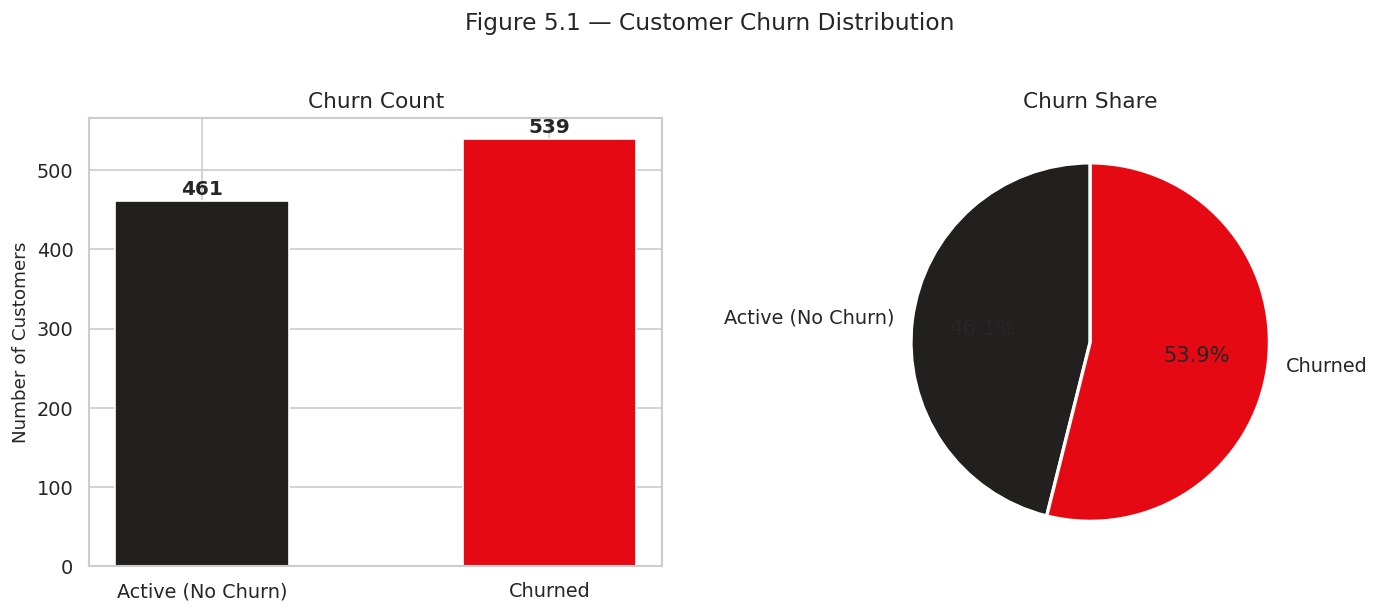

Churn rate: 53.90%  (Churned: 539 / Total: 1,000)


In [ ]:
# ─────────────────────────────────────────────────────────────────────
#  EDA — UNIVARIATE ANALYSIS
# ─────────────────────────────────────────────────────────────────────

# Figure 5.1 — Churn Distribution (target variable)
churn_counts = df["churn"].value_counts()
churn_labels = ["Active (No Churn)", "Churned"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(churn_labels, [churn_counts[0], churn_counts[1]],
            color=[DARK, RED], edgecolor="white", width=0.5)
for i, v in enumerate([churn_counts[0], churn_counts[1]]):
    axes[0].text(i, v + 8, f"{v:,}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Churn Count"); axes[0].set_ylabel("Number of Customers")

axes[1].pie([churn_counts[0], churn_counts[1]],
            labels=churn_labels, autopct="%1.1f%%",
            colors=[DARK, RED], startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Churn Share")

plt.suptitle("Figure 5.1 — Customer Churn Distribution", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
print(f"Churn rate: {churn_counts[1]/len(df)*100:.2f}%  "
      f"(Churned: {churn_counts[1]:,} / Total: {len(df):,})")

Subscription Plan & Region Distribution

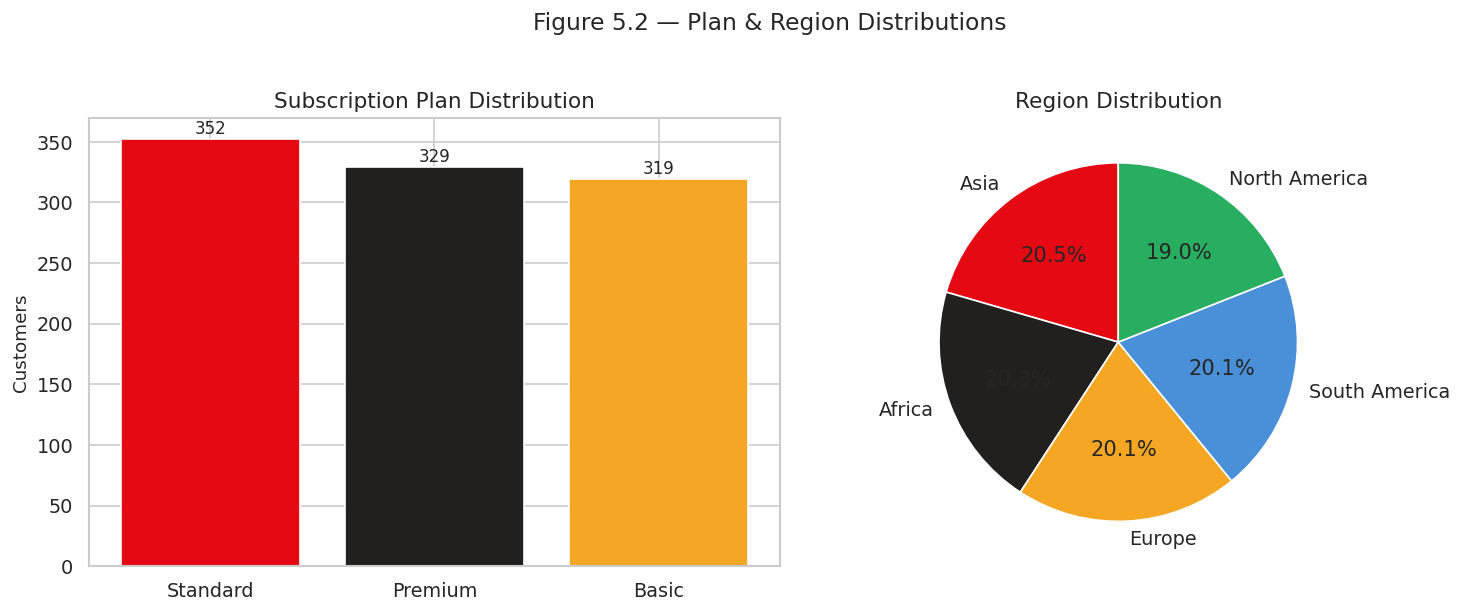

In [ ]:
# Figure 5.2 — Subscription Plan & Region Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subscription plan
plan_counts = df["subscription_plan"].value_counts()
axes[0].bar(plan_counts.index, plan_counts.values,
            color=PAL[:len(plan_counts)], edgecolor="white")
for i, v in enumerate(plan_counts.values):
    axes[0].text(i, v + 5, f"{v:,}", ha="center", fontsize=10)
axes[0].set_title("Subscription Plan Distribution")
axes[0].set_ylabel("Customers")

# Region
region_counts = df["region"].value_counts()
axes[1].pie(region_counts, labels=region_counts.index, autopct="%1.1f%%",
            colors=PAL[:len(region_counts)], startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Region Distribution")

plt.suptitle("Figure 5.2 — Plan & Region Distributions", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

Numeric Features Distributions

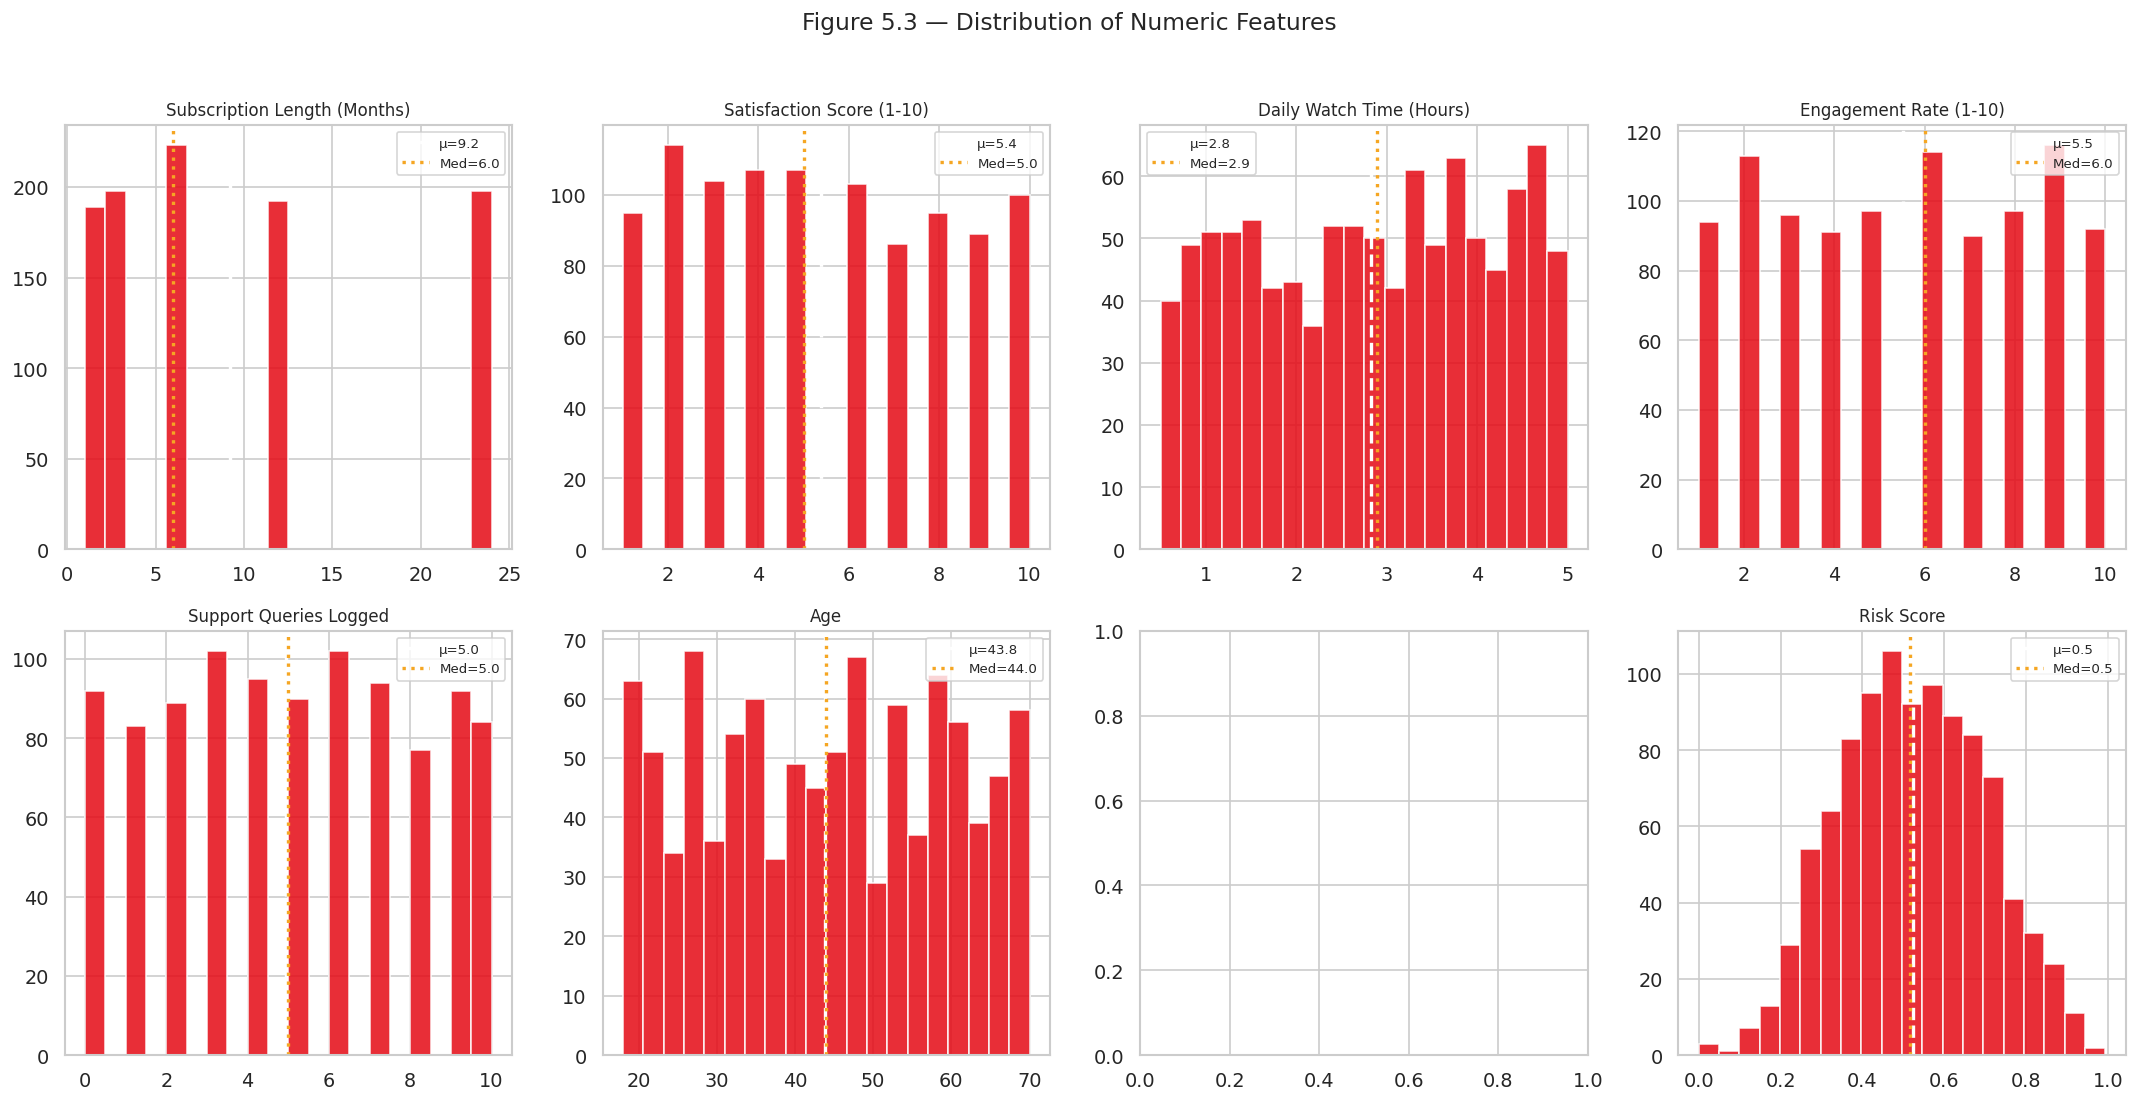

In [ ]:
# Figure 5.3 — Numeric Features Distributions
num_features = [
    ("subscription_length_months", "Subscription Length (Months)"),
    ("customer_satisfaction_score_110", "Satisfaction Score (1-10)"),
    ("daily_watch_time_hours", "Daily Watch Time (Hours)"),
    ("engagement_rate_110", "Engagement Rate (1-10)"),
    ("support_queries_logged", "Support Queries Logged"),
    ("age", "Age"),
    ("monthly_income_", "Monthly Income ($)"),
    ("risk_score", "Risk Score"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(num_features):
    if col in df.columns:
        axes[i].hist(df[col], bins=20, color=RED, edgecolor="white", alpha=0.85)
        axes[i].axvline(df[col].mean(), color="white", linestyle="--",
                        linewidth=2, label=f"μ={df[col].mean():.1f}")
        axes[i].axvline(df[col].median(), color=GOLD, linestyle=":",
                        linewidth=2, label=f"Med={df[col].median():.1f}")
        axes[i].set_title(label, fontsize=10); axes[i].legend(fontsize=8)

plt.suptitle("Figure 5.3 — Distribution of Numeric Features", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

Categorical Features Bar Charts

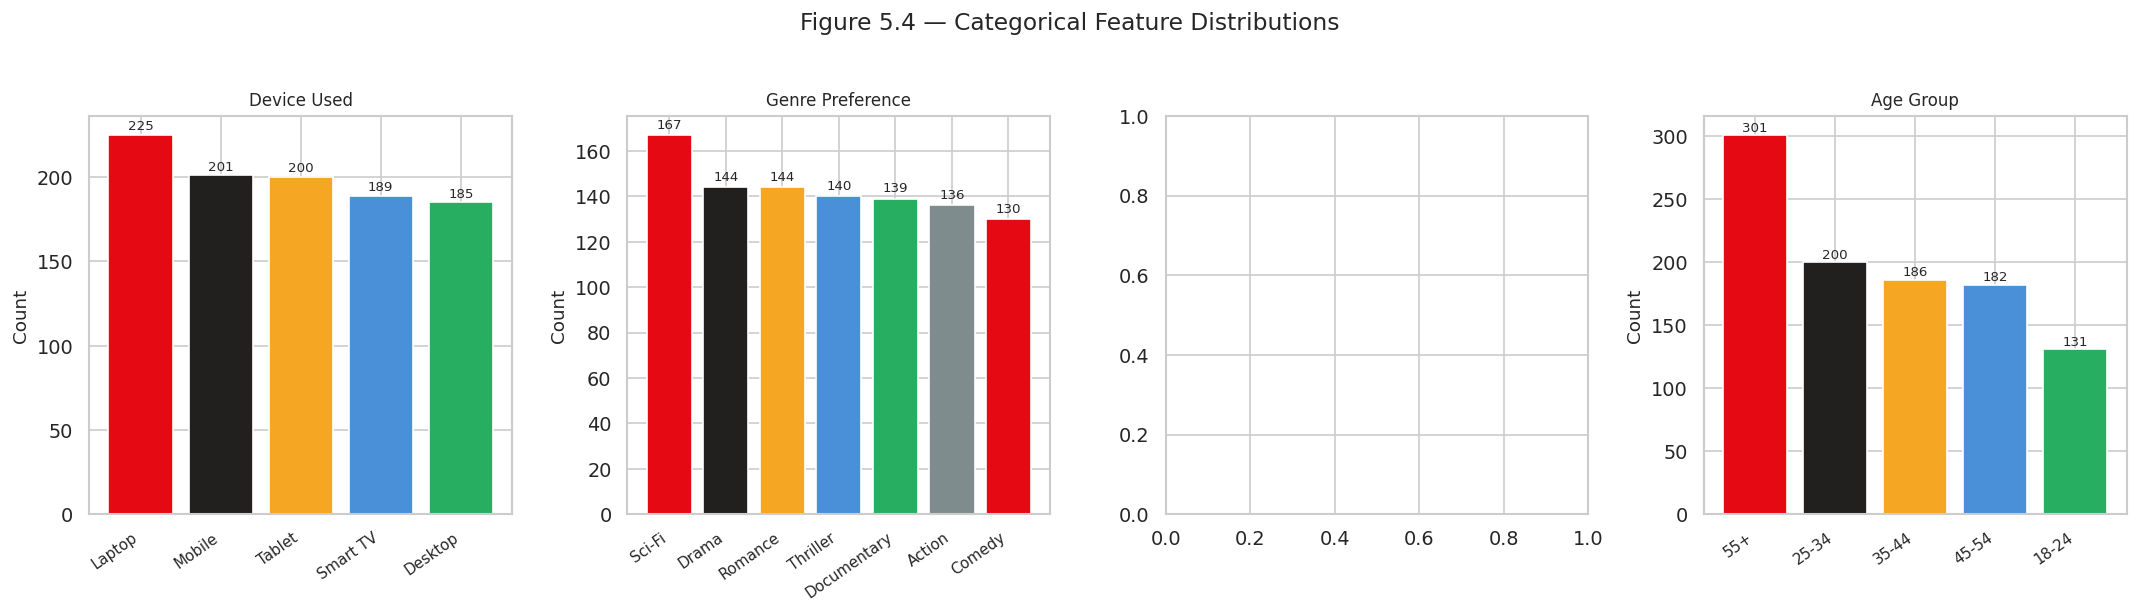

In [ ]:
# Figure 5.4 — Categorical Features Bar Charts
cat_features = [
    ("device_used_most_often", "Device Used"),
    ("genre_preference", "Genre Preference"),
    ("payment_history_on_timedelayed", "Payment History"),
    ("age_group", "Age Group"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, (col, label) in enumerate(cat_features):
    if col in df.columns:
        counts = df[col].value_counts()
        axes[i].bar(range(len(counts)), counts.values,
                    color=PAL[:len(counts)], edgecolor="white")
        axes[i].set_xticks(range(len(counts)))
        axes[i].set_xticklabels(counts.index, rotation=35, ha="right", fontsize=9)
        axes[i].set_title(label, fontsize=10)
        axes[i].set_ylabel("Count")
        for j, v in enumerate(counts.values):
            axes[i].text(j, v + 3, str(v), ha="center", fontsize=8)

plt.suptitle("Figure 5.4 — Categorical Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

EDA BIVARIATE ANALYSIS

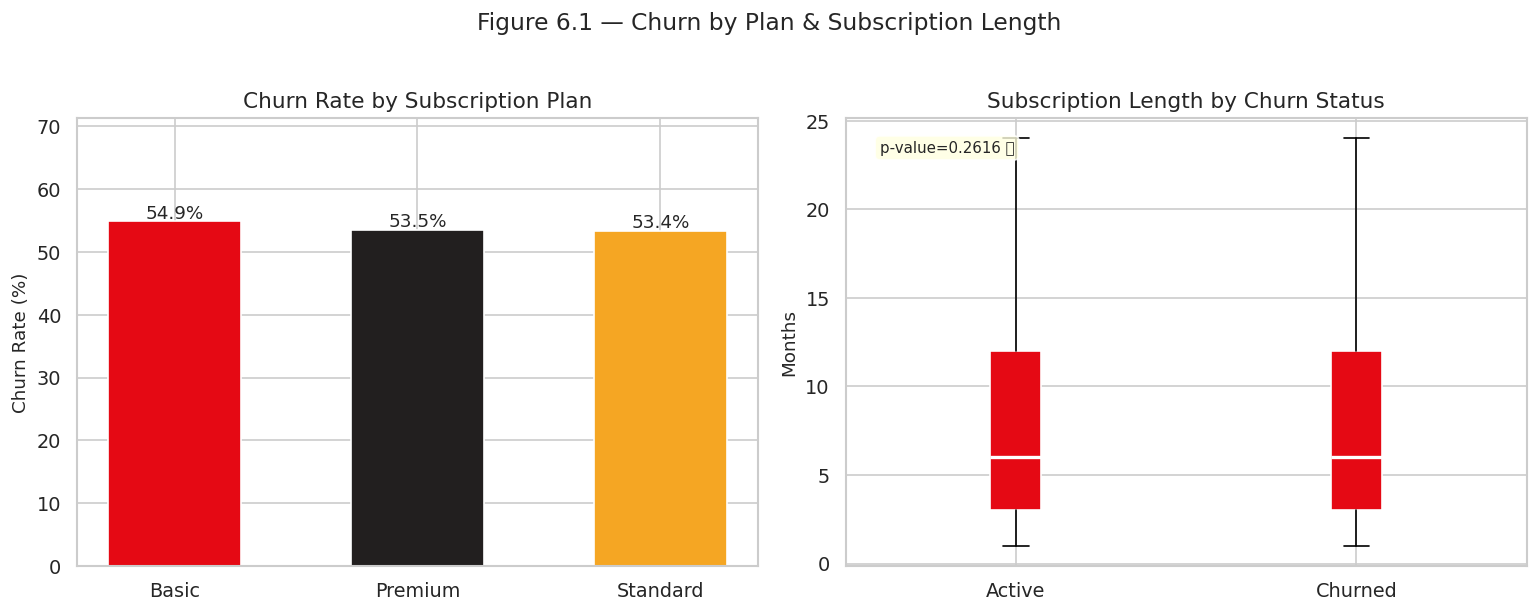

Active median tenure  : 6.0 months
Churned median tenure : 6.0 months
Mann-Whitney p-value  : 0.2616  →  No significant difference


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# EDA — BIVARIATE ANALYSIS (features vs. Churn)
# ─────────────────────────────────────────────────────────────────────

# Figure 6.1 — Churn Rate by Subscription Plan
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

churn_plan = df.groupby("subscription_plan")["churn"].mean().sort_values(ascending=False) * 100
bars = axes[0].bar(churn_plan.index, churn_plan.values,
                   color=PAL[:len(churn_plan)], edgecolor="white", width=0.55)
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{bar.get_height():.1f}%", ha="center", fontsize=11)
axes[0].set_title("Churn Rate by Subscription Plan")
axes[0].set_ylabel("Churn Rate (%)"); axes[0].set_ylim(0, churn_plan.max()*1.3)

# Subscription length vs churn (box)
churned = df[df["churn"]==1]["subscription_length_months"]
active  = df[df["churn"]==0]["subscription_length_months"]
axes[1].boxplot([active, churned], labels=["Active", "Churned"],
                patch_artist=True,
                boxprops=dict(facecolor=RED, color="white"),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_title("Subscription Length by Churn Status")
axes[1].set_ylabel("Months")

# Mann-Whitney U test
u, p = stats.mannwhitneyu(active, churned, alternative="two-sided")
axes[1].text(0.05, 0.95, f"p-value={p:.4f} {'✅' if p<0.05 else '❌'}",
             transform=axes[1].transAxes, fontsize=9, va="top",
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Figure 6.1 — Churn by Plan & Subscription Length", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
print(f"Active median tenure  : {active.median():.1f} months")
print(f"Churned median tenure : {churned.median():.1f} months")
print(f"Mann-Whitney p-value  : {p:.4f}  →  {'Significant difference' if p<0.05 else 'No significant difference'}")

Satisfaction, Engagement & Watch Time vs Churn

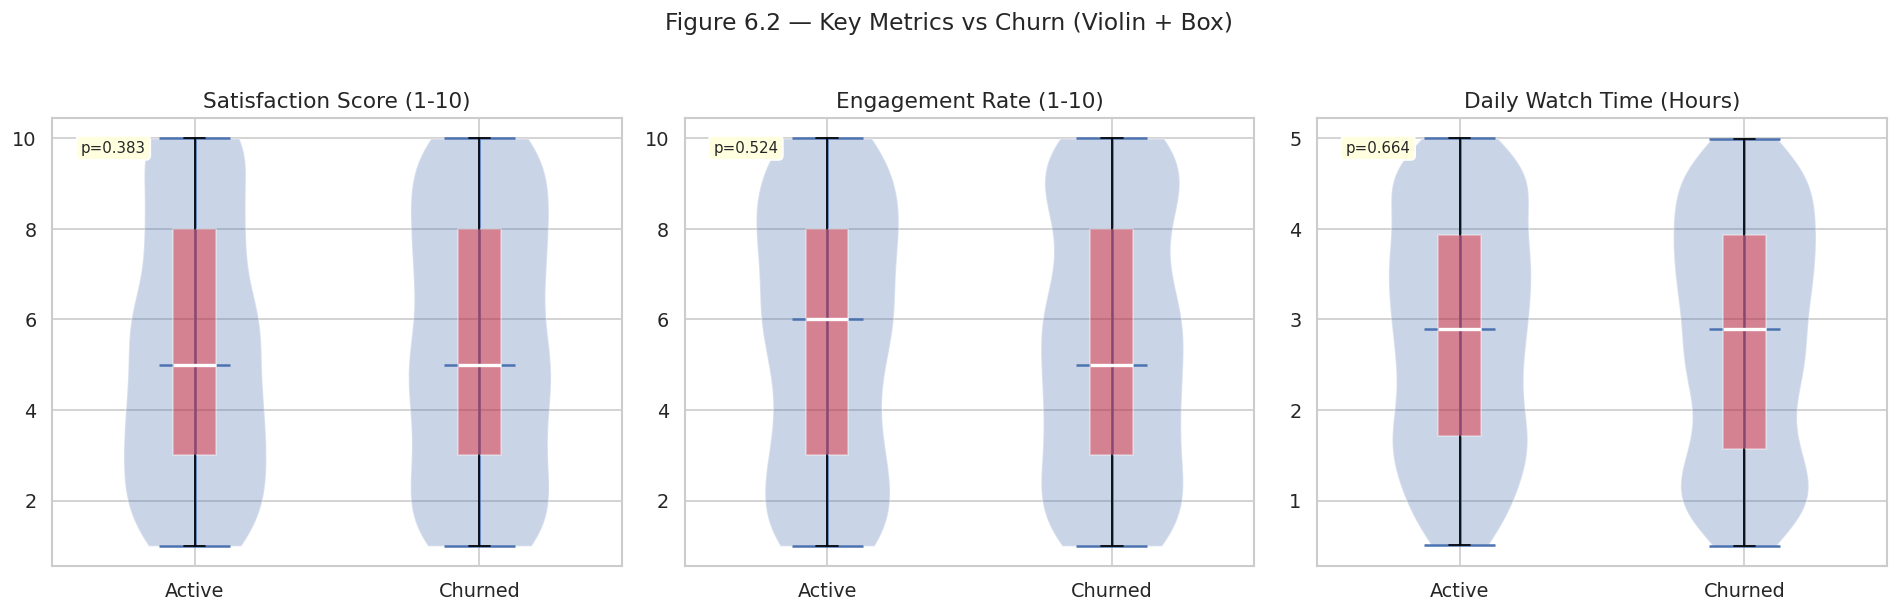

In [ ]:
# Figure 6.2 — Satisfaction, Engagement & Watch Time vs Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
comparisons = [
    ("customer_satisfaction_score_110", "Satisfaction Score (1-10)"),
    ("engagement_rate_110", "Engagement Rate (1-10)"),
    ("daily_watch_time_hours", "Daily Watch Time (Hours)"),
]
for i, (col, label) in enumerate(comparisons):
    g0 = df[df["churn"]==0][col].dropna()
    g1 = df[df["churn"]==1][col].dropna()
    axes[i].violinplot([g0, g1], positions=[0, 1], showmedians=True)
    axes[i].boxplot([g0, g1], positions=[0, 1], patch_artist=True,
                    boxprops=dict(facecolor=RED, color="white", alpha=0.4),
                    medianprops=dict(color="white", linewidth=2),
                    widths=0.15)
    axes[i].set_xticks([0, 1]); axes[i].set_xticklabels(["Active", "Churned"])
    axes[i].set_title(label)
    u, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    axes[i].text(0.05, 0.95, f"p={p:.3f}", transform=axes[i].transAxes,
                 fontsize=9, va="top", bbox=dict(boxstyle="round", facecolor="lightyellow"))

plt.suptitle("Figure 6.2 — Key Metrics vs Churn (Violin + Box)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

Churn Rate by Categorical Variables

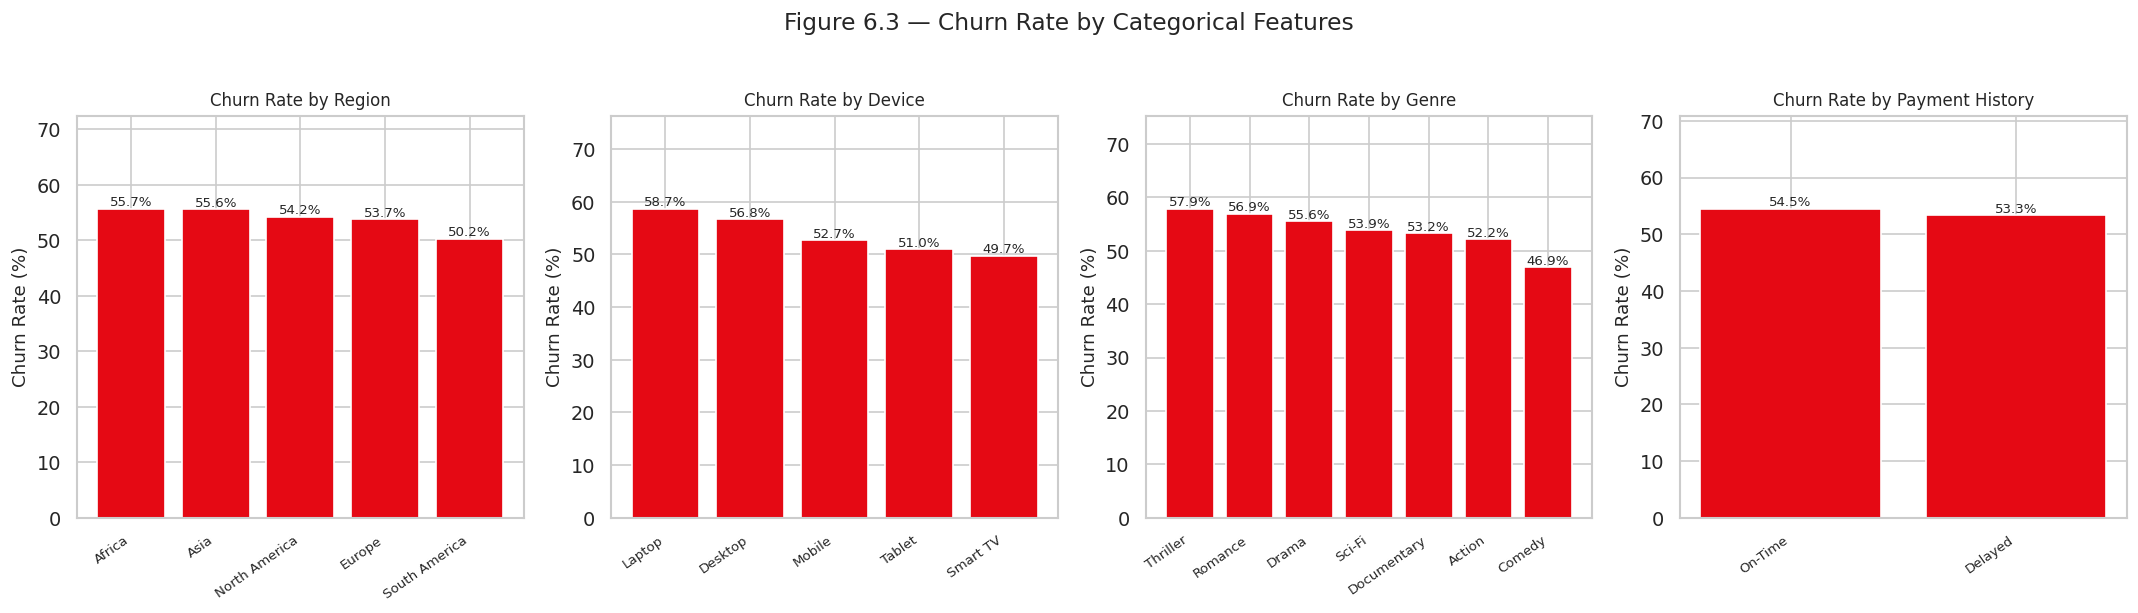

In [ ]:
# Figure 6.3 — Churn Rate by Categorical Variables
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
cat_comparisons = [
    ("region", "Region"),
    ("device_used_most_often", "Device"),
    ("genre_preference", "Genre"),
    ("payment_history_ontime_delayed", "Payment History"),
]
for i, (col, label) in enumerate(cat_comparisons):
    cr = df.groupby(col)["churn"].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(range(len(cr)), cr.values, color=RED, edgecolor="white")
    axes[i].set_xticks(range(len(cr)))
    axes[i].set_xticklabels(cr.index, rotation=35, ha="right", fontsize=8)
    axes[i].set_title(f"Churn Rate by {label}", fontsize=10)
    axes[i].set_ylabel("Churn Rate (%)"); axes[i].set_ylim(0, cr.max()*1.3)
    for bar, val in zip(bars, cr.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, val+0.5,
                     f"{val:.1f}%", ha="center", fontsize=8)

plt.suptitle("Figure 6.3 — Churn Rate by Categorical Features", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

Age, Income & Support Queries vs Churn

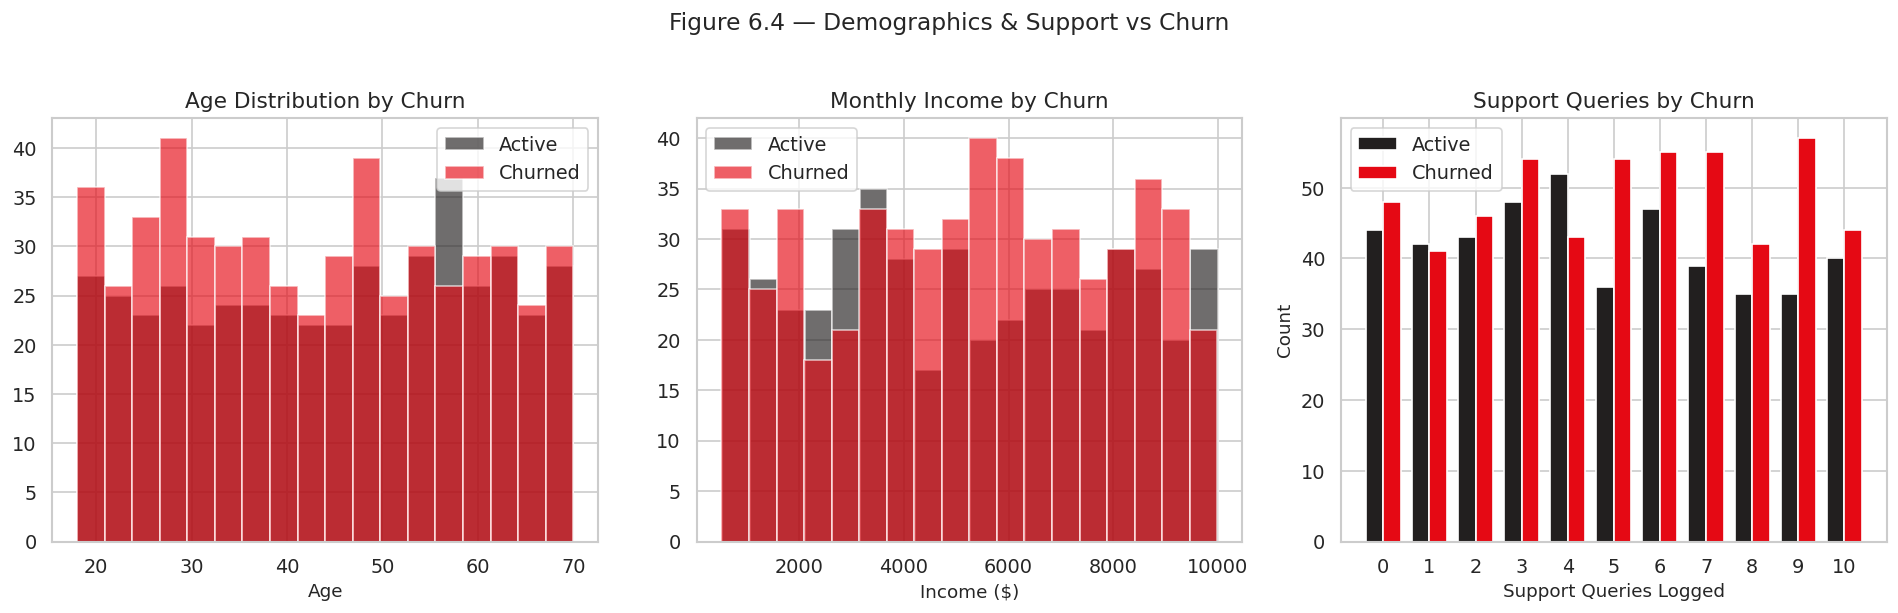

In [ ]:
# Figure 6.4 — Age, Income & Support Queries vs Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution by churn
for label, colour, val in [("Active", DARK, 0), ("Churned", RED, 1)]:
    axes[0].hist(df[df["churn"]==val]["age"], bins=18,
                 color=colour, alpha=0.65, label=label, edgecolor="white")
axes[0].set_title("Age Distribution by Churn"); axes[0].set_xlabel("Age"); axes[0].legend()

# Monthly income by churn
for label, colour, val in [("Active", DARK, 0), ("Churned", RED, 1)]:
    axes[1].hist(df[df["churn"]==val]["monthly_income"], bins=18,
                 color=colour, alpha=0.65, label=label, edgecolor="white")
axes[1].set_title("Monthly Income by Churn"); axes[1].set_xlabel("Income ($)"); axes[1].legend()

# Support queries — bar comparison
sq_churn  = df[df["churn"]==1]["support_queries_logged"].value_counts().sort_index()
sq_active = df[df["churn"]==0]["support_queries_logged"].value_counts().sort_index()
x = sorted(set(sq_churn.index) | set(sq_active.index))
w = 0.38
axes[2].bar([i-w/2 for i in range(len(x))], [sq_active.get(v,0) for v in x],
            w, label="Active", color=DARK, edgecolor="white")
axes[2].bar([i+w/2 for i in range(len(x))], [sq_churn.get(v,0) for v in x],
            w, label="Churned", color=RED, edgecolor="white")
axes[2].set_xticks(range(len(x))); axes[2].set_xticklabels(x)
axes[2].set_title("Support Queries by Churn"); axes[2].legend()
axes[2].set_xlabel("Support Queries Logged"); axes[2].set_ylabel("Count")

plt.suptitle("Figure 6.4 — Demographics & Support vs Churn", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

EDA MULTIVARIATE ANALYSIS

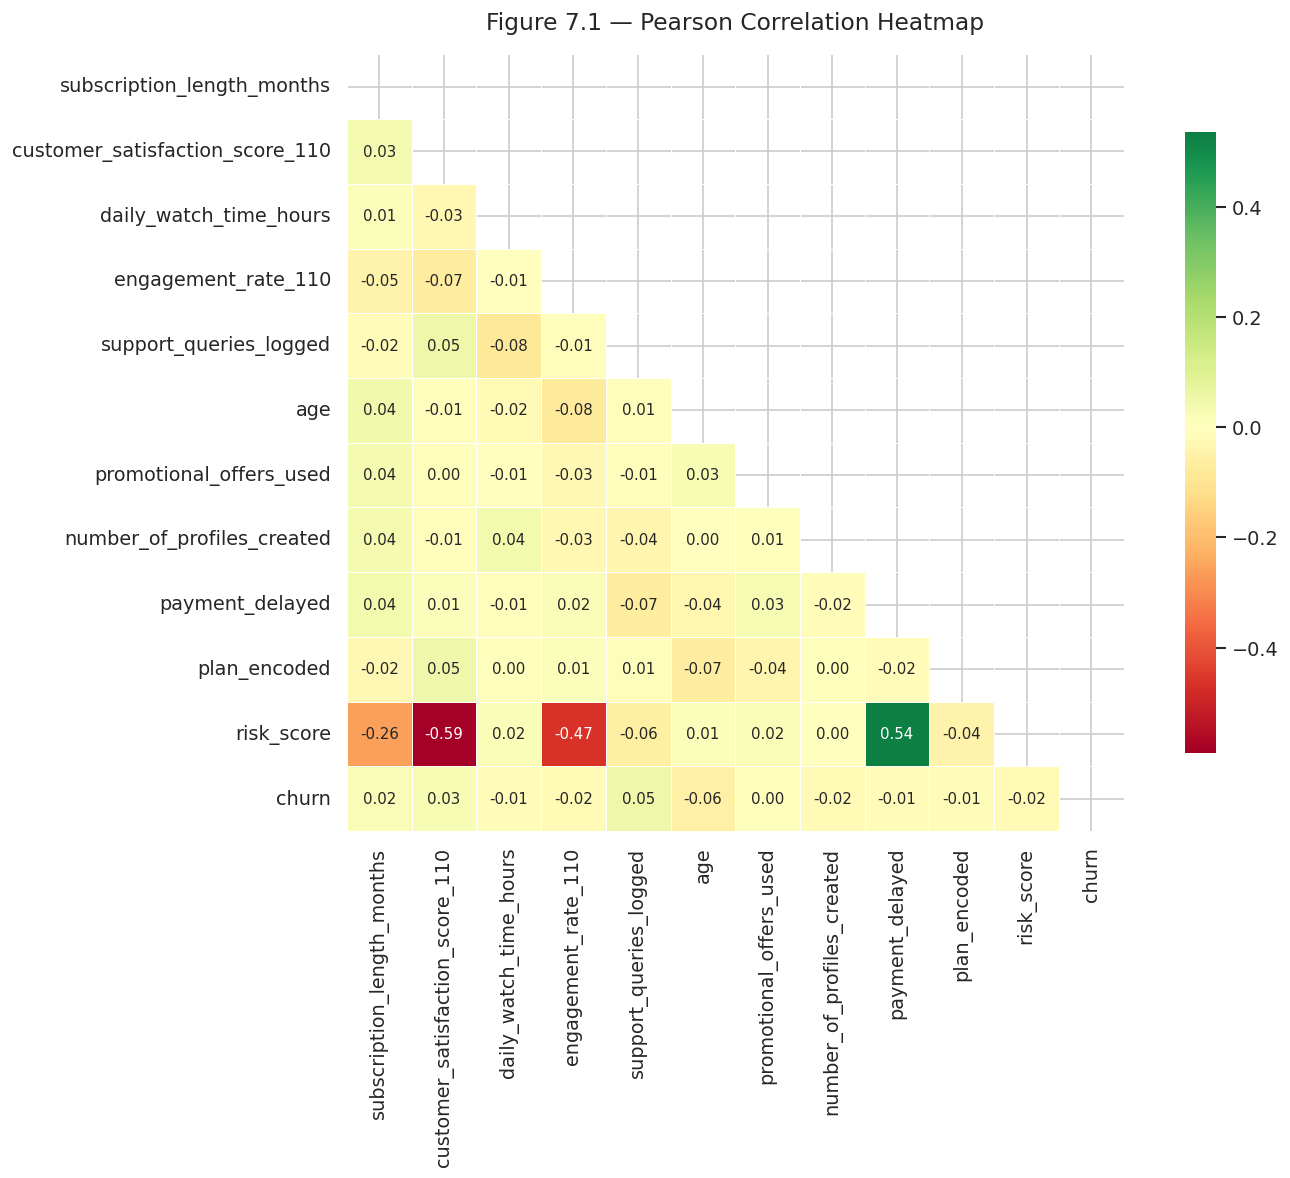


Top features correlated with churn:
age                                0.0551
support_queries_logged             0.0467
customer_satisfaction_score_110    0.0279
subscription_length_months         0.0241
number_of_profiles_created         0.0225
engagement_rate_110                0.0206
risk_score                         0.0200
daily_watch_time_hours             0.0129
payment_delayed                    0.0119
plan_encoded                       0.0109


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# EDA — MULTIVARIATE ANALYSIS
# ─────────────────────────────────────────────────────────────────────

# Figure 7.1 — Pearson Correlation Heatmap
num_cols_corr = [
    "subscription_length_months", "customer_satisfaction_score_110",
    "daily_watch_time_hours", "engagement_rate_110",
    "support_queries_logged", "age", "monthly_income_",
    "promotional_offers_used", "number_of_profiles_created",
    "payment_delayed", "plan_encoded", "risk_score", "churn"
]
num_cols_corr = [c for c in num_cols_corr if c in df.columns]
corr = df[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.4, ax=ax,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 9})
ax.set_title("Figure 7.1 — Pearson Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout(); plt.show()

# Top correlations with churn
print("\nTop features correlated with churn:")
top_corr = corr["churn"].drop("churn").abs().sort_values(ascending=False).head(10)
print(top_corr.round(4).to_string())

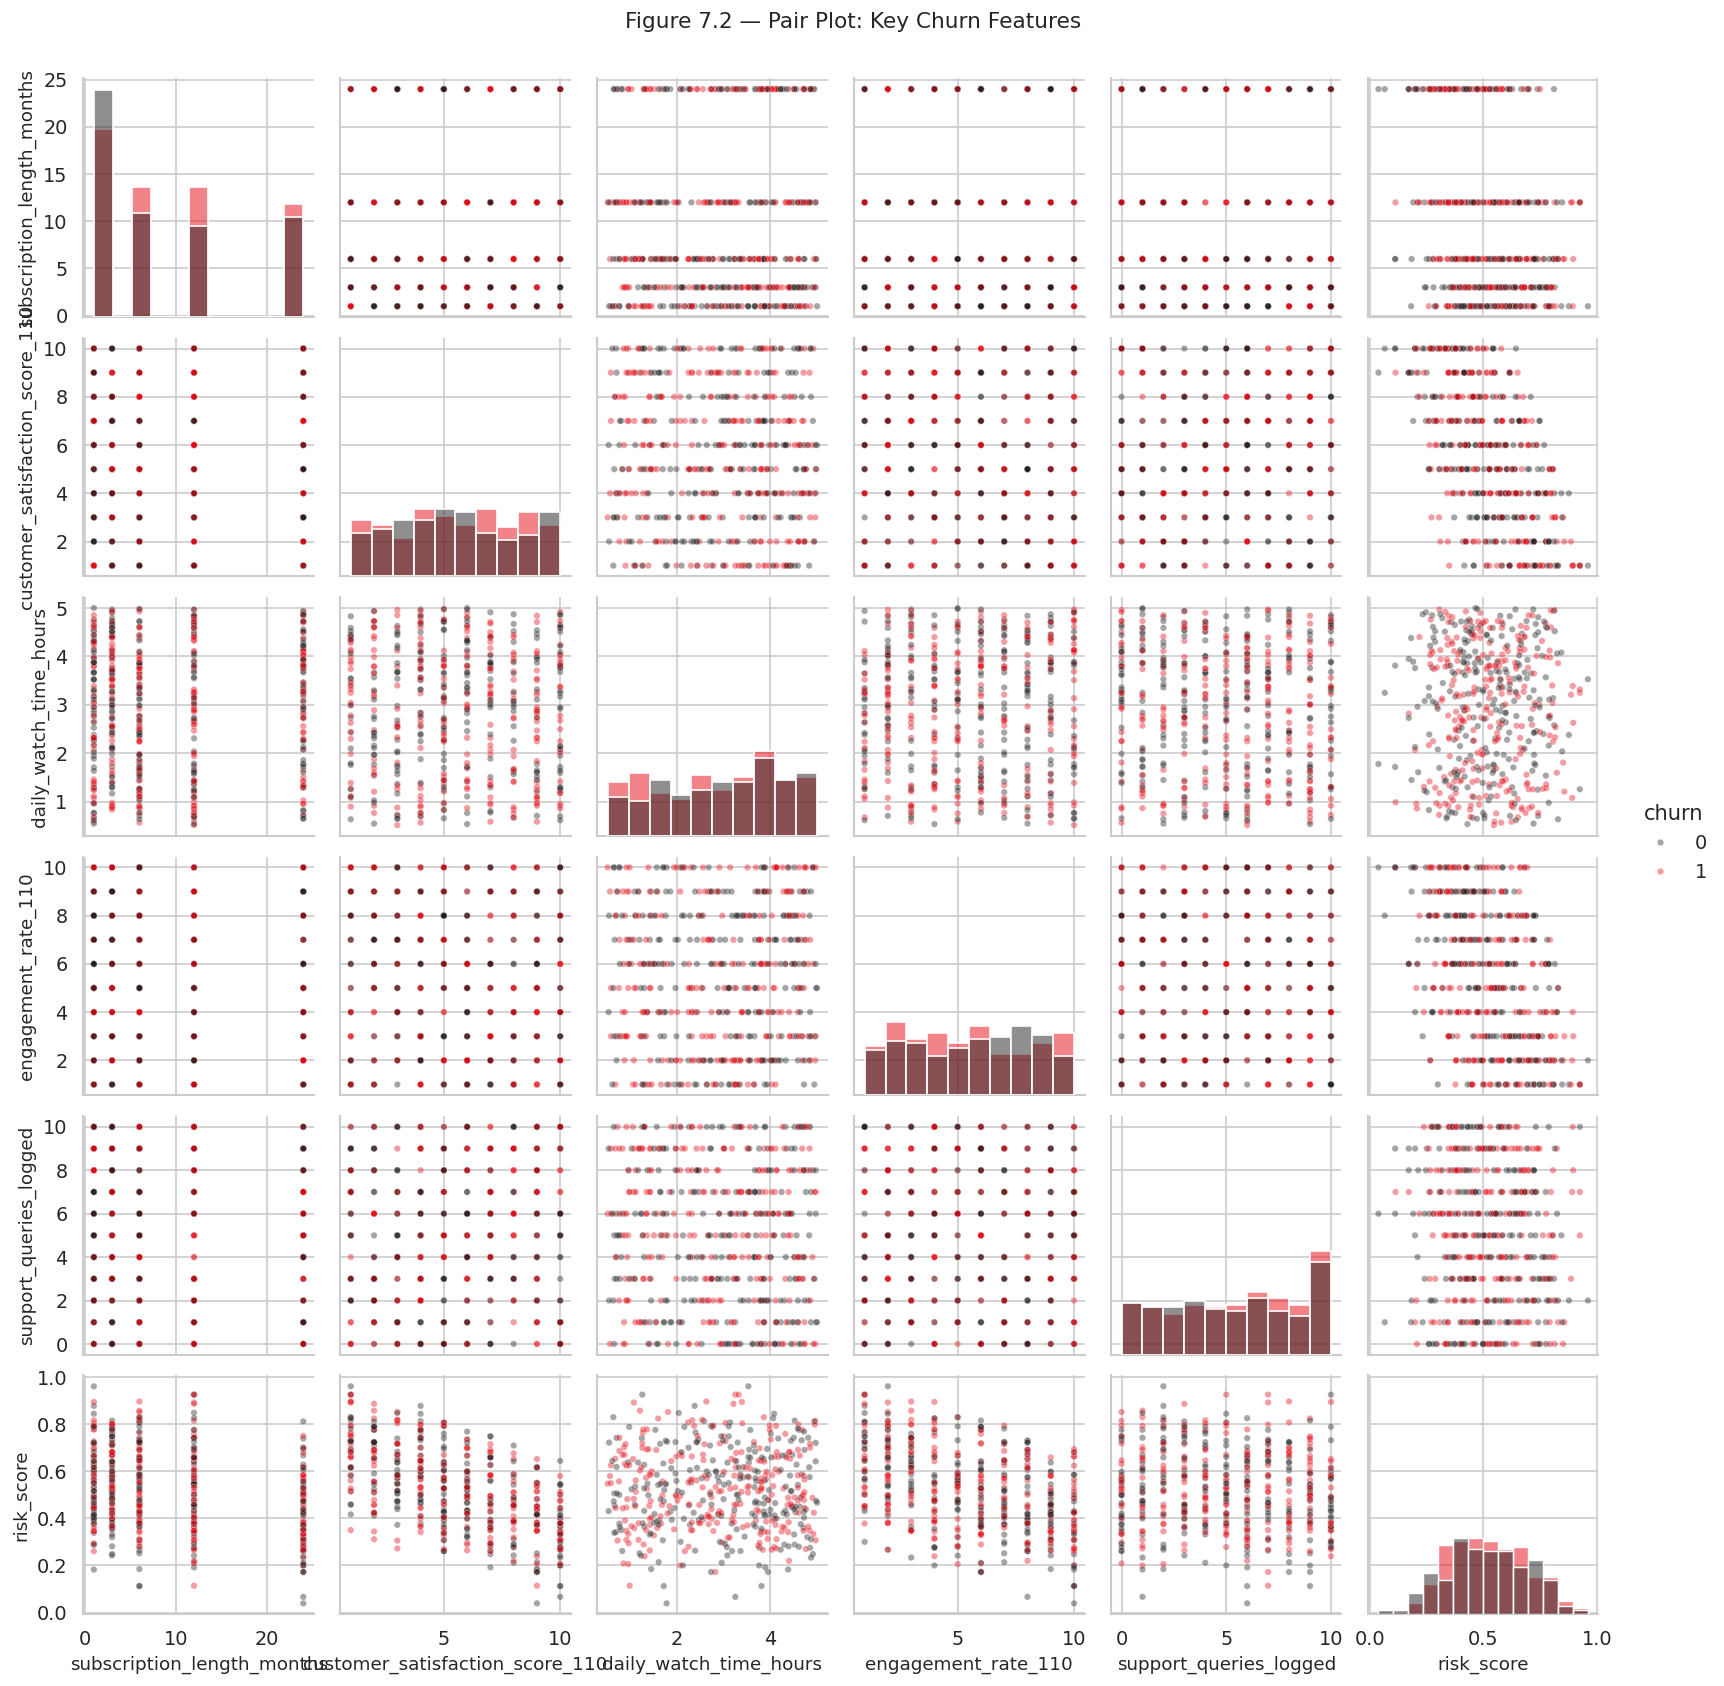

In [ ]:
# Figure 7.2 — Pair Plot (key features)
pair_cols = [
    "subscription_length_months", "customer_satisfaction_score_110",
    "daily_watch_time_hours", "engagement_rate_110",
    "support_queries_logged", "risk_score", "churn"
]
pair_cols = [c for c in pair_cols if c in df.columns]
pair_sample = df[pair_cols].sample(min(500, len(df)), random_state=42)
pp = sns.pairplot(pair_sample, hue="churn",
                   palette={0: DARK, 1: RED},
                   diag_kind="hist",
                   plot_kws={"alpha": 0.4, "s": 15}, height=2.3)
pp.fig.suptitle("Figure 7.2 — Pair Plot: Key Churn Features", fontsize=13, y=1.02)
plt.show()

 Heatmap: Subscription Plan × Region Churn Rates

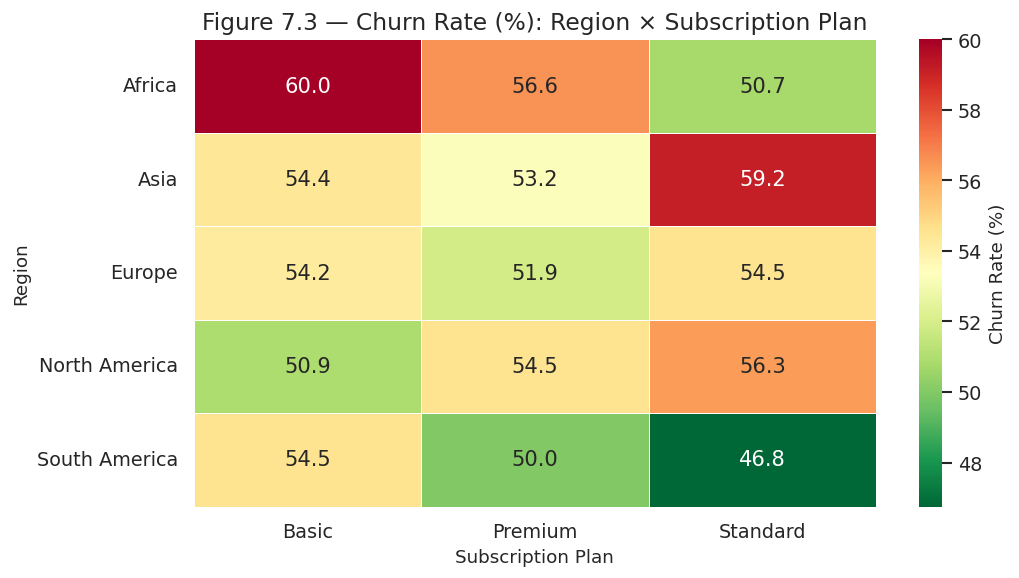

In [ ]:
# Figure 7.3 — Heatmap: Subscription Plan × Region Churn Rates
pivot = df.pivot_table(values="churn", index="region",
                        columns="subscription_plan", aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.3, ax=ax, cbar_kws={"label": "Churn Rate (%)"})
ax.set_title("Figure 7.3 — Churn Rate (%): Region × Subscription Plan", fontsize=14)
ax.set_xlabel("Subscription Plan"); ax.set_ylabel("Region")
plt.tight_layout(); plt.show()

PCA 2D Scatter: Active vs Churned

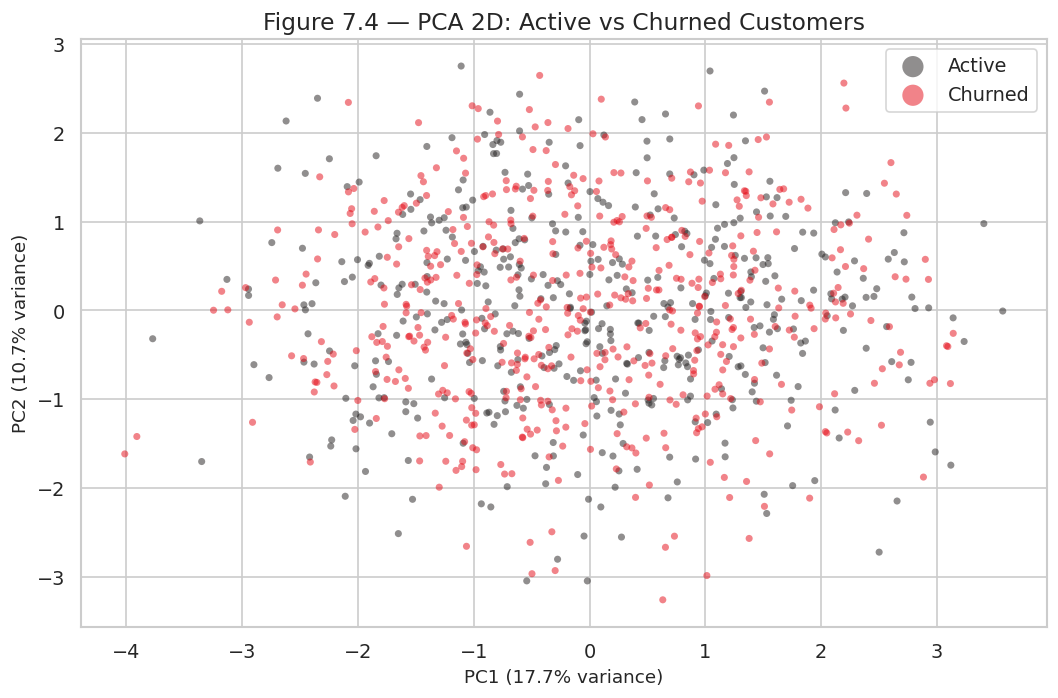

PC1 + PC2 explain 28.3% of total variance


In [ ]:
# Figure 7.4 — PCA 2D Scatter: Active vs Churned
pca_features = [
    "subscription_length_months", "customer_satisfaction_score_110",
    "daily_watch_time_hours", "engagement_rate_110",
    "support_queries_logged", "age", "monthly_income_",
    "promotional_offers_used", "number_of_profiles_created",
    "payment_delayed", "plan_encoded", "risk_score"
]
pca_features = [c for c in pca_features if c in df.columns]
pca_df = df[pca_features + ["churn"]].dropna()
X_pca  = StandardScaler().fit_transform(pca_df[pca_features])
pca2   = PCA(n_components=2, random_state=42)
X_2d   = pca2.fit_transform(X_pca)
var    = pca2.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
for label, colour, name in [(0, DARK, "Active"), (1, RED, "Churned")]:
    m = pca_df["churn"].values == label
    ax.scatter(X_2d[m, 0], X_2d[m, 1], c=colour, label=name,
               alpha=0.5, s=18, edgecolors="none")
ax.set_xlabel(f"PC1 ({var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}% variance)")
ax.set_title("Figure 7.4 — PCA 2D: Active vs Churned Customers", fontsize=14)
ax.legend(markerscale=3)
plt.tight_layout(); plt.show()
print(f"PC1 + PC2 explain {sum(var):.1f}% of total variance")

Risk Score Distribution by Churn

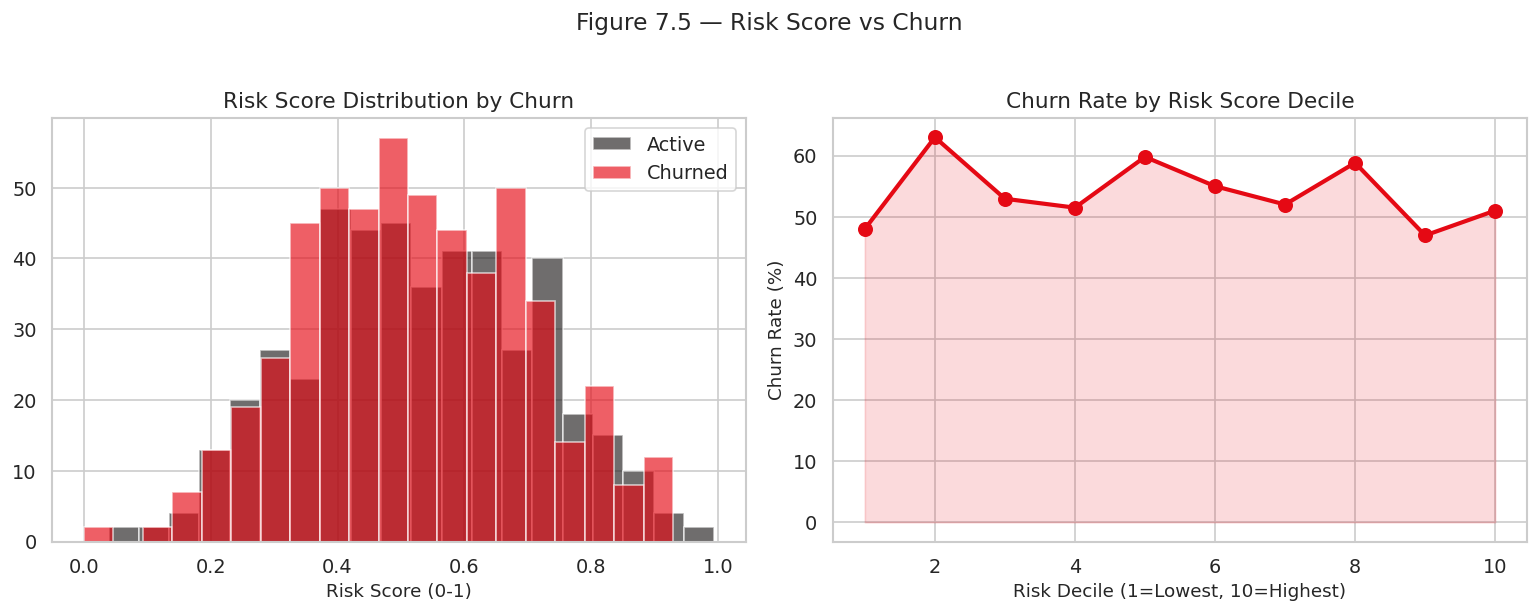

In [ ]:
# Figure 7.5 — Risk Score Distribution by Churn
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram overlay
for label, colour, val in [("Active", DARK, 0), ("Churned", RED, 1)]:
    axes[0].hist(df[df["churn"]==val]["risk_score"], bins=20,
                 color=colour, alpha=0.65, label=label, edgecolor="white")
axes[0].set_title("Risk Score Distribution by Churn")
axes[0].set_xlabel("Risk Score (0-1)"); axes[0].legend()

# Churn rate across risk score deciles
df["risk_decile"] = pd.qcut(df["risk_score"], q=10, labels=False, duplicates="drop") + 1
risk_churn = df.groupby("risk_decile")["churn"].mean() * 100
axes[1].plot(risk_churn.index, risk_churn.values, "o-",
             color=RED, linewidth=2.5, markersize=8)
axes[1].fill_between(risk_churn.index, risk_churn.values, alpha=0.15, color=RED)
axes[1].set_title("Churn Rate by Risk Score Decile")
axes[1].set_xlabel("Risk Decile (1=Lowest, 10=Highest)")
axes[1].set_ylabel("Churn Rate (%)")

plt.suptitle("Figure 7.5 — Risk Score vs Churn", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

ENCODING AND PREPROCESSING FOR MACHINE LEARNING

In [ ]:
# ─────────────────────────────────────────────────────────────────────
#  ENCODING & PREPROCESSING FOR MACHINE LEARNING
# ─────────────────────────────────────────────────────────────────────

# 8a — Select modelling features
feature_cols = [
    "subscription_length_months",
    "customer_satisfaction_score_110",
    "daily_watch_time_hours",
    "engagement_rate_110",
    "support_queries_logged",
    "age",
    "monthly_income_",
    "promotional_offers_used",
    "number_of_profiles_created",
    "payment_delayed",
    "plan_encoded",
    "risk_score",
    "subscription_plan",
    "device_used_most_often",
    "genre_preference",
    "region",
]
feature_cols = [c for c in feature_cols if c in df.columns]
TARGET = "churn"

model_df = df[feature_cols + [TARGET]].copy().dropna(subset=[TARGET])
print(f"Modelling dataset: {len(model_df):,} rows × {len(feature_cols)} features")

Modelling dataset: 1,000 rows × 15 features


In [ ]:
# 8b — One-hot encode categorical variables
cat_cols = model_df.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"Encoding {len(cat_cols)} categorical column(s): {cat_cols}")

model_enc = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)
bool_cols  = model_enc.select_dtypes(bool).columns
model_enc[bool_cols] = model_enc[bool_cols].astype(int)

X = model_enc.drop(columns=[TARGET])
y = model_enc[TARGET].astype(int)
feature_names = X.columns.tolist()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Class distribution  — 0 (Active): {(y==0).sum():,}  |  1 (Churned): {(y==1).sum():,}")
print(f"Churn rate          : {y.mean()*100:.2f}%")

Encoding 4 categorical column(s): ['subscription_plan', 'device_used_most_often', 'genre_preference', 'region']

Feature matrix shape: (1000, 27)
Class distribution  — 0 (Active): 461  |  1 (Churned): 539
Churn rate          : 53.90%


Stratified 70/30 train-test split

In [ ]:
# 8c — Stratified 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train churn rate: {y_train.mean()*100:.2f}%  |  "
      f"Test churn rate: {y_test.mean()*100:.2f}%  ✅ (stratification confirmed)")

Train: 700  |  Test: 300
Train churn rate: 53.86%  |  Test churn rate: 54.00%  ✅ (stratification confirmed)


 SMOTE oversampling on training set only

In [ ]:
# 8d — SMOTE oversampling on training set only
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After  SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")
print("✅  SMOTE applied — training classes balanced.")

Before SMOTE: {1: 377, 0: 323}
After  SMOTE: {0: 377, 1: 377}
✅  SMOTE applied — training classes balanced.


In [ ]:
# 8e — StandardScaler (fit on train, transform both)
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train_res)
X_test_sc    = scaler.transform(X_test)
print("✅  StandardScaler applied.")

✅  StandardScaler applied.


Mutual Information Feature Importance

Top 15 features by Mutual Information:


,Feature,MI_Score
0,device_used_most_often_Mobile,0.032664
1,genre_preference_Drama,0.031634
2,region_Asia,0.026472
3,subscription_plan_Premium,0.020175
4,plan_encoded,0.017612
5,payment_delayed,0.015573
6,genre_preference_Documentary,0.014189
7,daily_watch_time_hours,0.009217
8,device_used_most_often_Laptop,0.003152
9,customer_satisfaction_score_110,0.001234


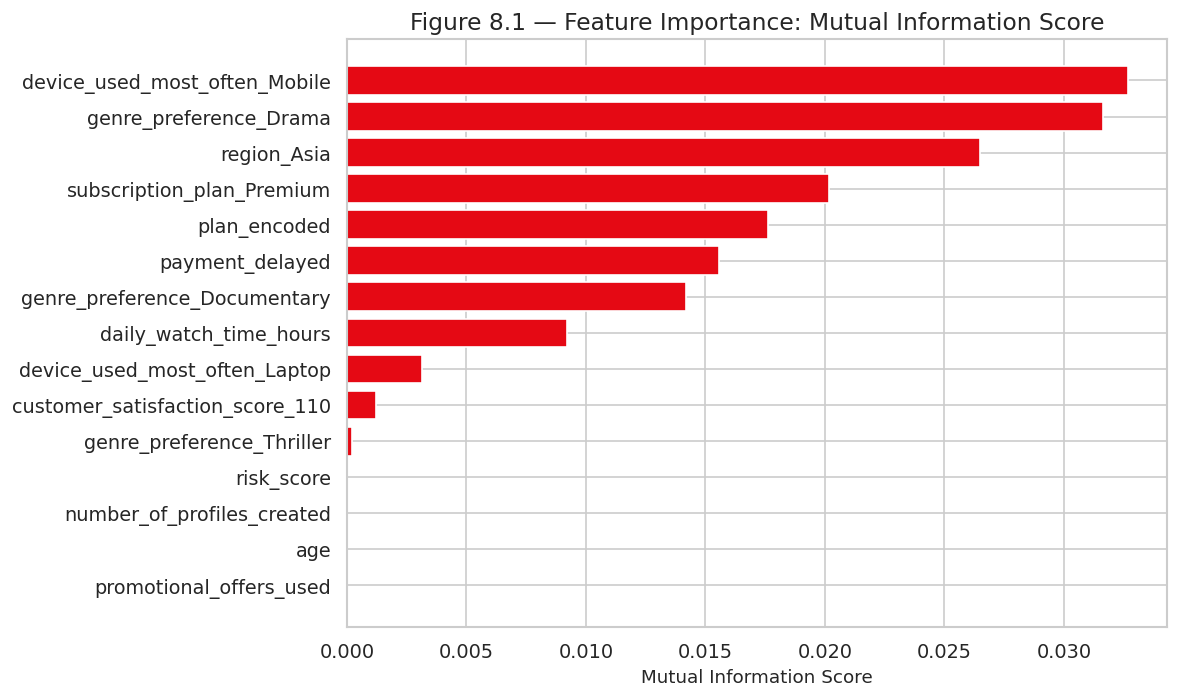

In [ ]:
# Figure 8.1 — Mutual Information Feature Importance
mi = mutual_info_classif(X_train_sc, y_train_res, random_state=42)
mi_df = pd.DataFrame({"Feature": feature_names, "MI_Score": mi})\
          .sort_values("MI_Score", ascending=False)

print("Top 15 features by Mutual Information:")
display(mi_df.head(15).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
top_mi = mi_df.head(15)
ax.barh(top_mi["Feature"][::-1], top_mi["MI_Score"][::-1],
        color=RED, edgecolor="white")
ax.set_title("Figure 8.1 — Feature Importance: Mutual Information Score", fontsize=14)
ax.set_xlabel("Mutual Information Score")
plt.tight_layout(); plt.show()

K-MEANS CLUSTERING

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# K-MEANS CLUSTERING (Unsupervised Segmentation)
# Objective: Segment customers into groups — Active vs Likely to Churn
# ─────────────────────────────────────────────────────────────────────

cluster_cols = [
    "subscription_length_months", "customer_satisfaction_score_110",
    "daily_watch_time_hours", "engagement_rate_110",
    "support_queries_logged", "payment_delayed", "risk_score"
]
cluster_cols = [c for c in cluster_cols if c in df.columns]
cluster_df   = df[cluster_cols].dropna()
X_cluster    = StandardScaler().fit_transform(cluster_df)
print(f"Clustering on {len(cluster_df):,} records | features: {cluster_cols}")

Clustering on 1,000 records | features: ['subscription_length_months', 'customer_satisfaction_score_110', 'daily_watch_time_hours', 'engagement_rate_110', 'support_queries_logged', 'payment_delayed', 'risk_score']


Elbow Method + Silhouette

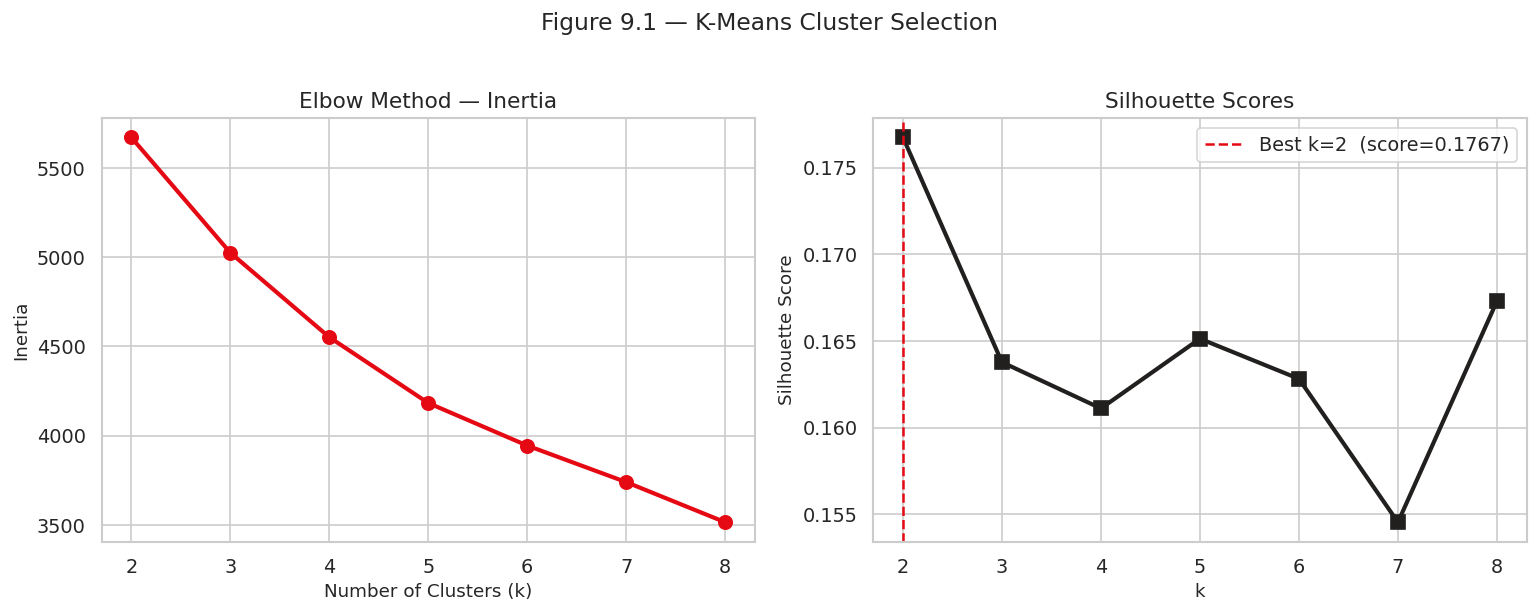

Best k: 2  |  Silhouette = 0.1767


In [ ]:
# Figure 9.1 — Elbow Method + Silhouette
inertias, sil_scores = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, "o-", color=RED, linewidth=2.5, markersize=8)
axes[0].set_title("Elbow Method — Inertia")
axes[0].set_xlabel("Number of Clusters (k)"); axes[0].set_ylabel("Inertia")

best_k = k_range.start + sil_scores.index(max(sil_scores))
axes[1].plot(list(k_range), sil_scores, "s-", color=DARK, linewidth=2.5, markersize=8)
axes[1].axvline(best_k, color=RED, linestyle="--",
                label=f"Best k={best_k}  (score={max(sil_scores):.4f})")
axes[1].set_title("Silhouette Scores"); axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score"); axes[1].legend()

plt.suptitle("Figure 9.1 — K-Means Cluster Selection", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
print(f"Best k: {best_k}  |  Silhouette = {max(sil_scores):.4f}")

Final K-Means (k=2): Active vs Likely to Churn

K-Means (k=2) Segment Distribution:
segment
Active             535
Likely to Churn    465

Silhouette Score     : 0.1767  (closer to +1 is better)
Davies-Bouldin Index : 2.0101  (lower is better)


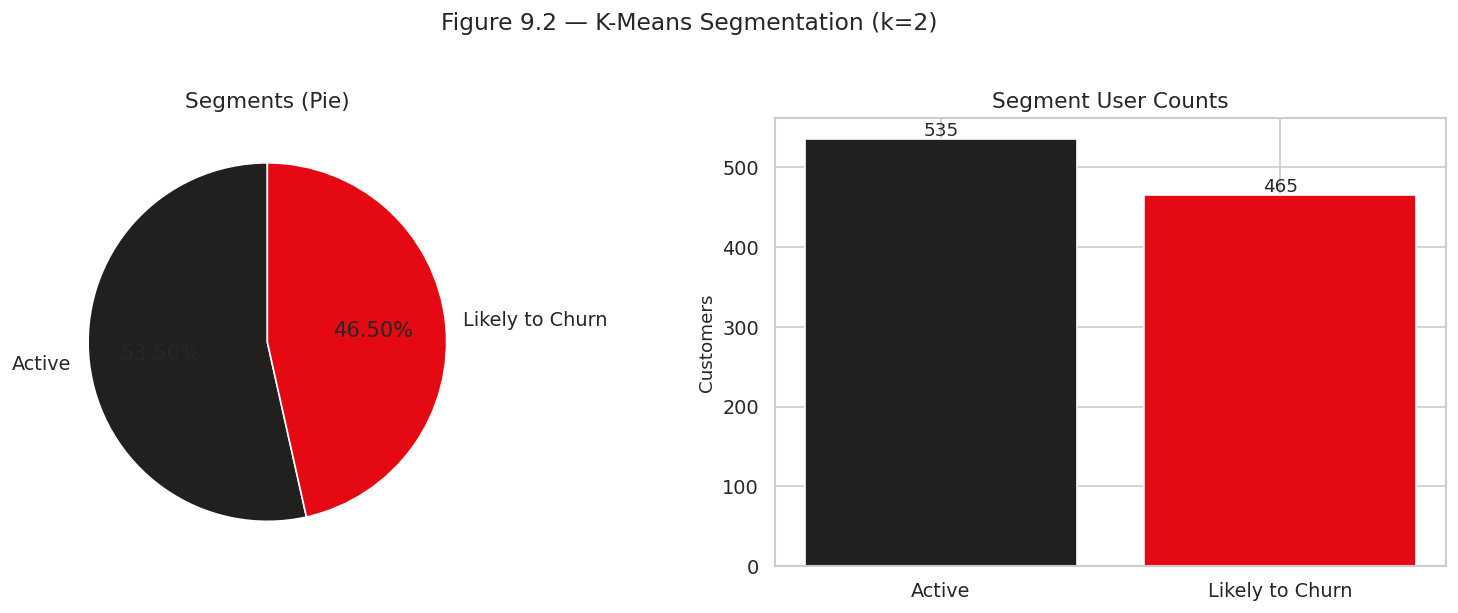

In [ ]:
# Figure 9.2 — Final K-Means (k=2): Active vs Likely to Churn
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
km_final.fit(X_cluster)
cluster_df = cluster_df.copy()
cluster_df["cluster"] = km_final.labels_

# Map cluster labels to segments (higher risk_score = Likely to Churn)
means = cluster_df.groupby("cluster")["risk_score"].mean()
churn_cluster = means.idxmax()
cluster_df["segment"] = cluster_df["cluster"].map(
    {churn_cluster: "Likely to Churn", 1 - churn_cluster: "Active"})

seg_counts = cluster_df["segment"].value_counts()
sil_k2 = silhouette_score(X_cluster, km_final.labels_)
db_k2  = davies_bouldin_score(X_cluster, km_final.labels_)

print("K-Means (k=2) Segment Distribution:")
print(seg_counts.to_string())
print(f"\nSilhouette Score     : {sil_k2:.4f}  (closer to +1 is better)")
print(f"Davies-Bouldin Index : {db_k2:.4f}  (lower is better)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colours = {"Active": DARK, "Likely to Churn": RED}
col_list = [colours[t] for t in seg_counts.index]

axes[0].pie(seg_counts, labels=seg_counts.index, autopct="%1.2f%%",
            colors=col_list, startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[0].set_title("Segments (Pie)")

axes[1].bar(seg_counts.index, seg_counts.values, color=col_list, edgecolor="white")
for i, v in enumerate(seg_counts.values):
    axes[1].text(i, v + 5, f"{v:,}", ha="center", fontsize=11)
axes[1].set_title("Segment User Counts"); axes[1].set_ylabel("Customers")

plt.suptitle("Figure 9.2 — K-Means Segmentation (k=2)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

Cluster Profile Summary

─── Cluster Profile Comparison ───


,subscription_length_months,customer_satisfaction_score_110,daily_watch_time_hours,engagement_rate_110,support_queries_logged,payment_delayed,risk_score
segment,,,,,,,
Active,10.277,6.523,2.809,6.325,5.310,0.234,0.390
Likely to Churn,7.912,4.062,2.852,4.574,4.538,0.832,0.679


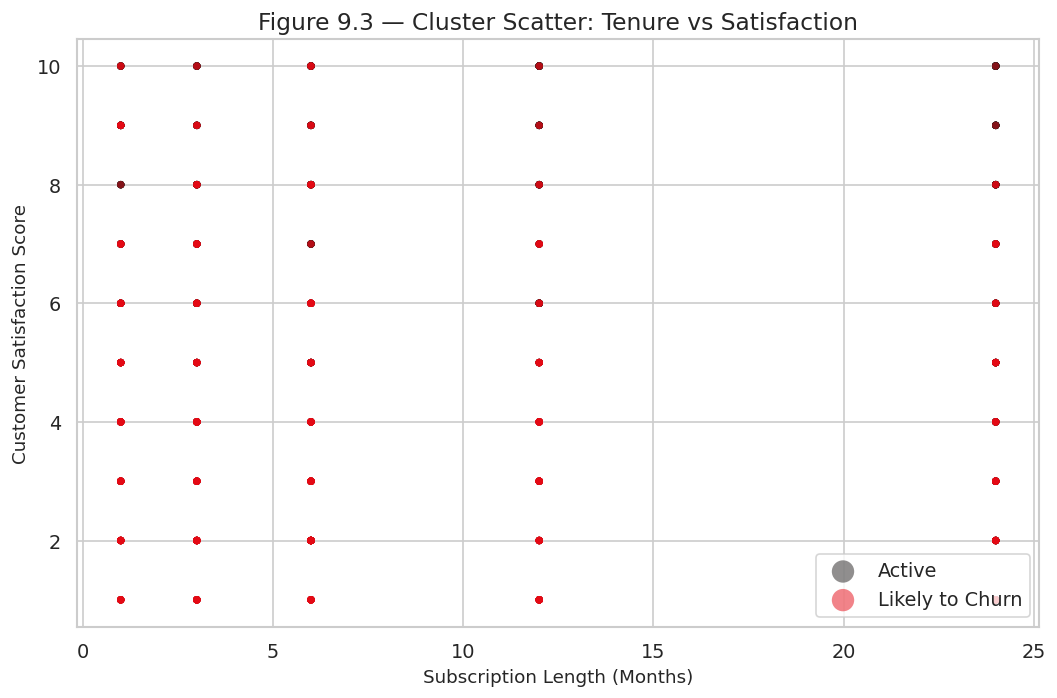

In [ ]:
# Figure 9.3 — Cluster Profile Summary
print("─── Cluster Profile Comparison ───")
display(cluster_df.groupby("segment")[cluster_cols].mean().round(3))

# Scatter: 2 key features coloured by cluster
fig, ax = plt.subplots(figsize=(9, 6))
for seg, colour in colours.items():
    m = cluster_df["segment"] == seg
    ax.scatter(
        cluster_df.loc[m, "subscription_length_months"],
        cluster_df.loc[m, "customer_satisfaction_score_110"],
        c=colour, label=seg, alpha=0.5, s=20, edgecolors="none")
ax.set_title("Figure 9.3 — Cluster Scatter: Tenure vs Satisfaction", fontsize=14)
ax.set_xlabel("Subscription Length (Months)")
ax.set_ylabel("Customer Satisfaction Score")
ax.legend(markerscale=3); plt.tight_layout(); plt.show()

DECISION TREE CLASSIFIER

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# DECISION TREE CLASSIFIER
# Objective: Classify churn with interpretable rules
# ─────────────────────────────────────────────────────────────────────

dt = DecisionTreeClassifier(max_depth=5, random_state=42,
                              class_weight="balanced",
                              min_samples_split=10,
                              min_samples_leaf=5)
dt.fit(X_train_sc, y_train_res)
y_dt_pred = dt.predict(X_test_sc)
y_dt_prob = dt.predict_proba(X_test_sc)[:, 1]

print("─── Decision Tree — Classification Report ───")
print(classification_report(y_test, y_dt_pred,
                              target_names=["Active", "Churned"], zero_division=0))
print(f"AUC-ROC  : {roc_auc_score(y_test, y_dt_prob):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_dt_pred):.4f}")

─── Decision Tree — Classification Report ───
              precision    recall  f1-score   support

      Active       0.42      0.47      0.44       138
     Churned       0.50      0.44      0.47       162

    accuracy                           0.46       300
   macro avg       0.46      0.46      0.46       300
weighted avg       0.46      0.46      0.46       300

AUC-ROC  : 0.4280
Accuracy : 0.4567


Decision Tree Confusion Matrix

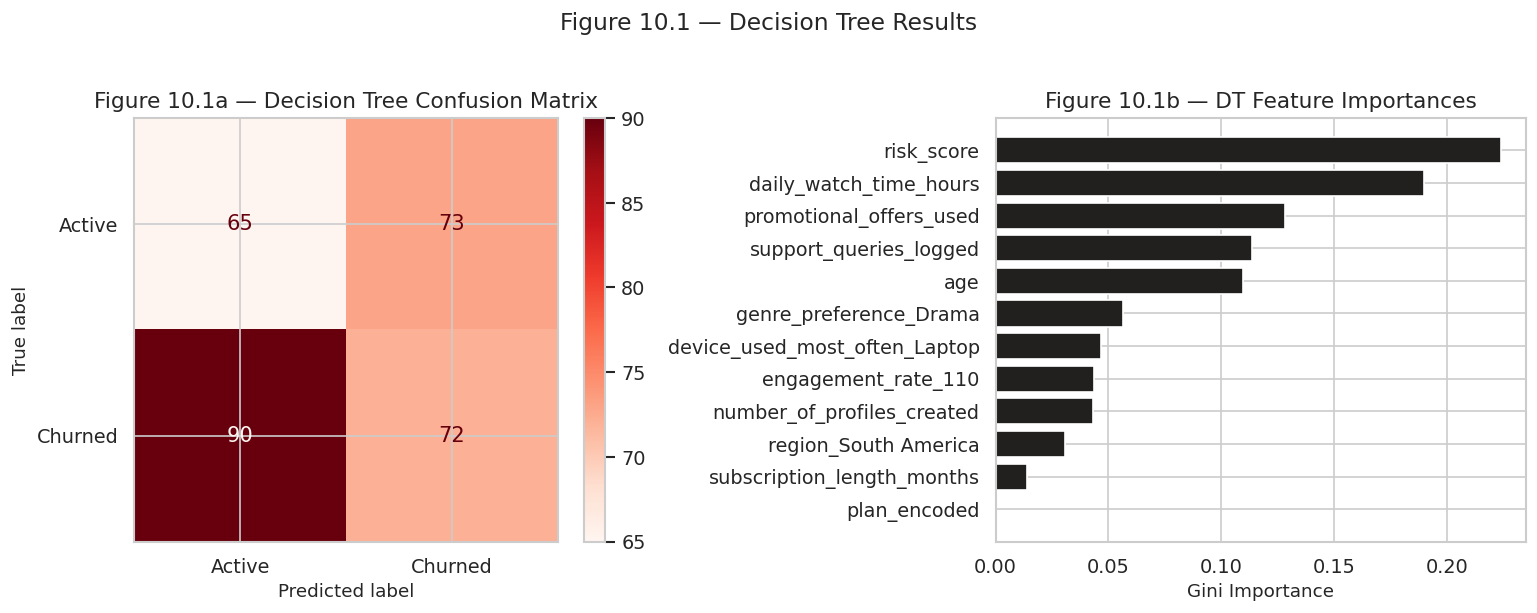


Top 8 Decision Rules (Feature Importances):
                      Feature  Importance
                   risk_score    0.223871
       daily_watch_time_hours    0.189844
      promotional_offers_used    0.128342
       support_queries_logged    0.113616
                          age    0.109662
       genre_preference_Drama    0.056667
device_used_most_often_Laptop    0.046680
          engagement_rate_110    0.043466


In [ ]:
# Figure 10.1 — Decision Tree Confusion Matrix + Feature Importances
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_dt_pred),
                        display_labels=["Active", "Churned"]).plot(ax=axes[0], cmap="Reds")
axes[0].set_title("Figure 10.1a — Decision Tree Confusion Matrix")

dt_fi = pd.DataFrame({"Feature": feature_names,
                       "Importance": dt.feature_importances_})\
          .sort_values("Importance", ascending=False).head(12)
axes[1].barh(dt_fi["Feature"][::-1], dt_fi["Importance"][::-1],
             color=DARK, edgecolor="white")
axes[1].set_title("Figure 10.1b — DT Feature Importances")
axes[1].set_xlabel("Gini Importance")

plt.suptitle("Figure 10.1 — Decision Tree Results", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("\nTop 8 Decision Rules (Feature Importances):")
print(dt_fi.head(8).to_string(index=False))

LOGISTIC REGRESSION

─── Logistic Regression — Classification Report ───
              precision    recall  f1-score   support

      Active       0.48      0.43      0.45       138
     Churned       0.55      0.59      0.57       162

    accuracy                           0.52       300
   macro avg       0.51      0.51      0.51       300
weighted avg       0.52      0.52      0.52       300

AUC-ROC  : 0.5012
Accuracy : 0.5200


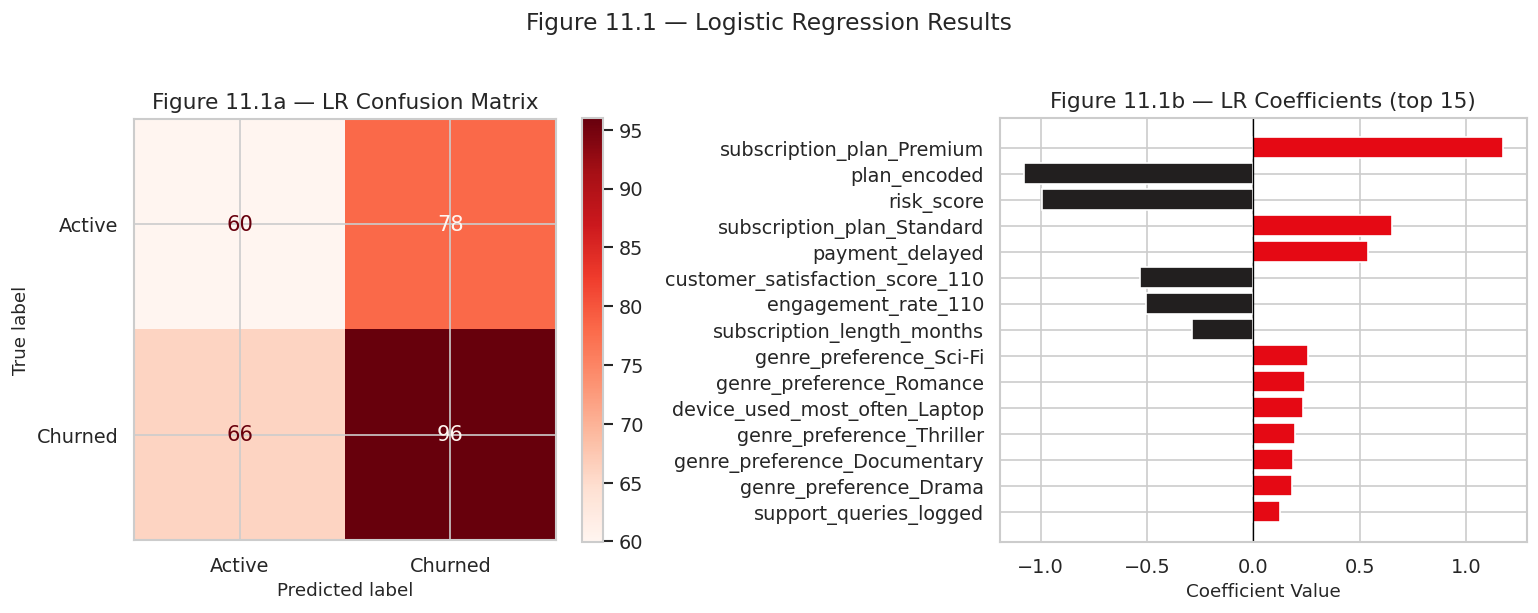

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# LOGISTIC REGRESSION (Baseline Model)
# ─────────────────────────────────────────────────────────────────────

lr = LogisticRegression(C=1.0, penalty="l2", solver="lbfgs",
                         max_iter=1000, random_state=42,
                         class_weight="balanced")
lr.fit(X_train_sc, y_train_res)
y_lr_pred = lr.predict(X_test_sc)
y_lr_prob = lr.predict_proba(X_test_sc)[:, 1]

print("─── Logistic Regression — Classification Report ───")
print(classification_report(y_test, y_lr_pred,
                              target_names=["Active", "Churned"], zero_division=0))
print(f"AUC-ROC  : {roc_auc_score(y_test, y_lr_prob):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_lr_pred):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_lr_pred),
                        display_labels=["Active", "Churned"]).plot(ax=axes[0], cmap="Reds")
axes[0].set_title("Figure 11.1a — LR Confusion Matrix")

# Coefficient plot (top features)
coef_df = pd.DataFrame({"Feature": feature_names, "Coefficient": lr.coef_[0]})\
            .reindex(pd.Series(lr.coef_[0]).abs().sort_values(ascending=False).index)\
            .head(15)
colours_coef = [RED if c > 0 else DARK for c in coef_df["Coefficient"]]
axes[1].barh(coef_df["Feature"][::-1], coef_df["Coefficient"][::-1],
             color=colours_coef[::-1], edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Figure 11.1b — LR Coefficients (top 15)")
axes[1].set_xlabel("Coefficient Value")

plt.suptitle("Figure 11.1 — Logistic Regression Results", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

 Random Forest + GridSearchCV Tuning

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# RANDOM FOREST — Default then GridSearchCV Tuning
# ─────────────────────────────────────────────────────────────────────

# 12a — Default Random Forest
rf_default = RandomForestClassifier(n_estimators=200, random_state=42,
                                     class_weight="balanced", n_jobs=-1)
rf_default.fit(X_train_sc, y_train_res)
y_rf_pred = rf_default.predict(X_test_sc)
y_rf_prob = rf_default.predict_proba(X_test_sc)[:, 1]
print(f"Default RF — AUC-ROC: {roc_auc_score(y_test, y_rf_prob):.4f}  "
      f"F1: {f1_score(y_test, y_rf_pred, zero_division=0):.4f}")

Default RF — AUC-ROC: 0.5109  F1: 0.5552


In [ ]:
# 12b — GridSearchCV (5-fold, may take ~1-2 minutes)
print("Running GridSearchCV... please wait ⏳")
param_grid = {
    "n_estimators"     : [100, 200, 300],
    "max_depth"        : [10, 20, None],
    "min_samples_split": [2, 5],
    "max_features"     : ["sqrt", "log2"],
}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs  = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced", n_jobs=-1),
    param_grid, cv=cv5, scoring="f1", n_jobs=-1, verbose=1)
gs.fit(X_train_sc, y_train_res)

print(f"\n✅  Best parameters : {gs.best_params_}")
print(f"   Best CV F1-Score : {gs.best_score_:.4f}")

Running GridSearchCV... please wait ⏳
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅  Best parameters : {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 200}
   Best CV F1-Score : 0.5595


In [ ]:
# 12c — Tuned Random Forest: full evaluation
rf_tuned   = gs.best_estimator_
y_rft_pred = rf_tuned.predict(X_test_sc)
y_rft_prob = rf_tuned.predict_proba(X_test_sc)[:, 1]

print("─── Random Forest (Tuned) — Full Classification Report ───")
print(classification_report(y_test, y_rft_pred,
                              target_names=["Active", "Churned"], zero_division=0))
print(f"AUC-ROC  : {roc_auc_score(y_test, y_rft_prob):.4f}")
print(f"Accuracy : {accuracy_score(y_test, y_rft_pred):.4f}")

# Save model
joblib.dump(rf_tuned, "netflix_churn_rf_model.pkl")
joblib.dump(scaler,   "netflix_churn_scaler.pkl")
print("\n✅  Model saved → netflix_churn_rf_model.pkl")

─── Random Forest (Tuned) — Full Classification Report ───
              precision    recall  f1-score   support

      Active       0.43      0.37      0.40       138
     Churned       0.52      0.58      0.55       162

    accuracy                           0.48       300
   macro avg       0.47      0.47      0.47       300
weighted avg       0.48      0.48      0.48       300

AUC-ROC  : 0.4949
Accuracy : 0.4833

✅  Model saved → netflix_churn_rf_model.pkl


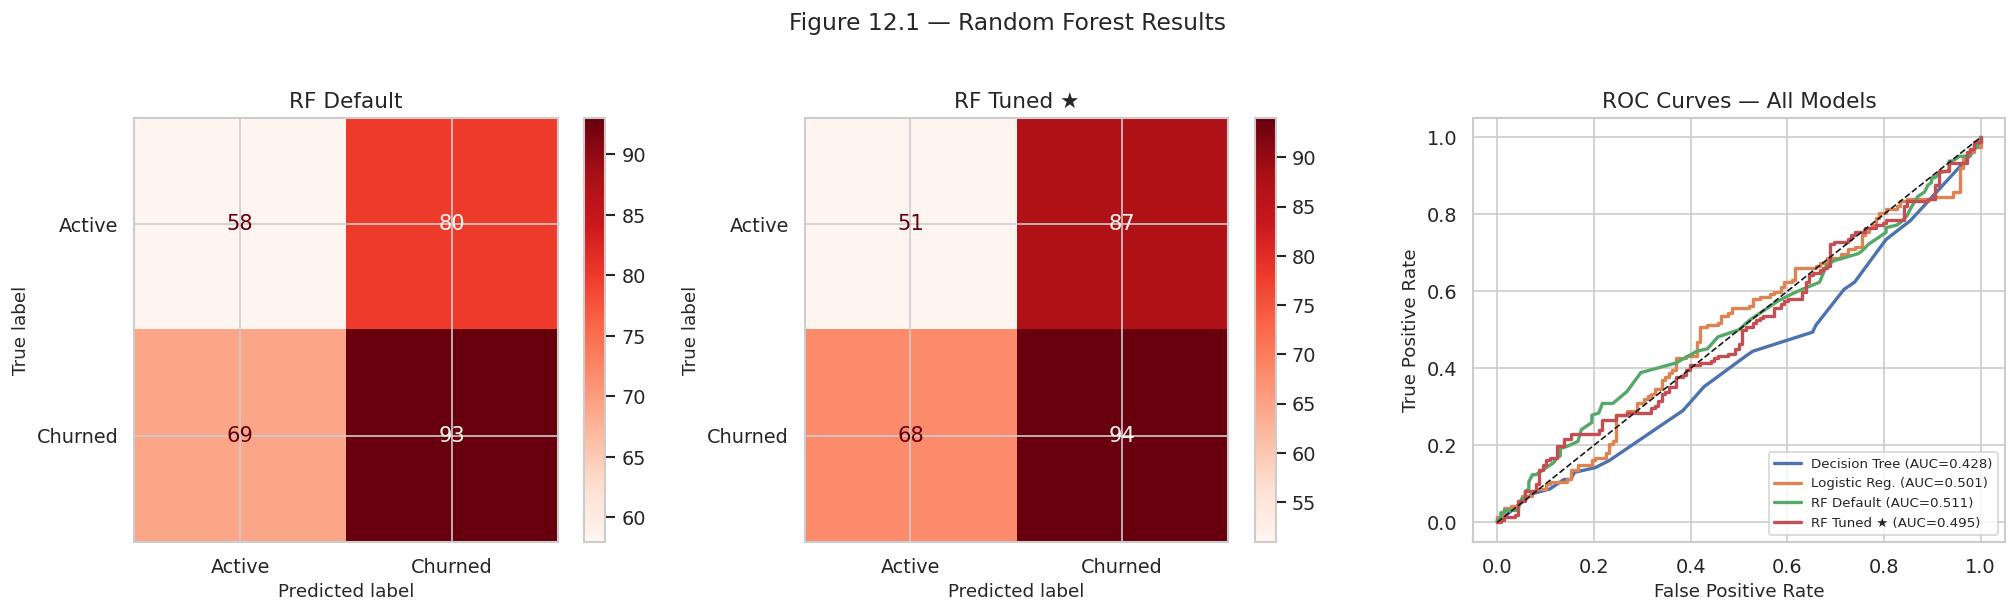

In [ ]:
# Figure 12.1 — Confusion Matrices (Default vs Tuned) + ROC curves
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_rf_pred),
                        display_labels=["Active","Churned"]).plot(ax=axes[0], cmap="Reds")
axes[0].set_title("RF Default")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_rft_pred),
                        display_labels=["Active","Churned"]).plot(ax=axes[1], cmap="Reds")
axes[1].set_title("RF Tuned ★")

# ROC curves — all models
for name, prob, col in [
    ("Decision Tree",   y_dt_prob,  GREY),
    ("Logistic Reg.",   y_lr_prob,  GOLD),
    ("RF Default",      y_rf_prob,  DARK),
    ("RF Tuned ★",      y_rft_prob, RED),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[2].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,prob):.3f})",
                 linewidth=2)
axes[2].plot([0,1],[0,1],"k--",linewidth=1)
axes[2].set_title("ROC Curves — All Models")
axes[2].set_xlabel("False Positive Rate"); axes[2].set_ylabel("True Positive Rate")
axes[2].legend(loc="lower right", fontsize=8)

plt.suptitle("Figure 12.1 — Random Forest Results", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

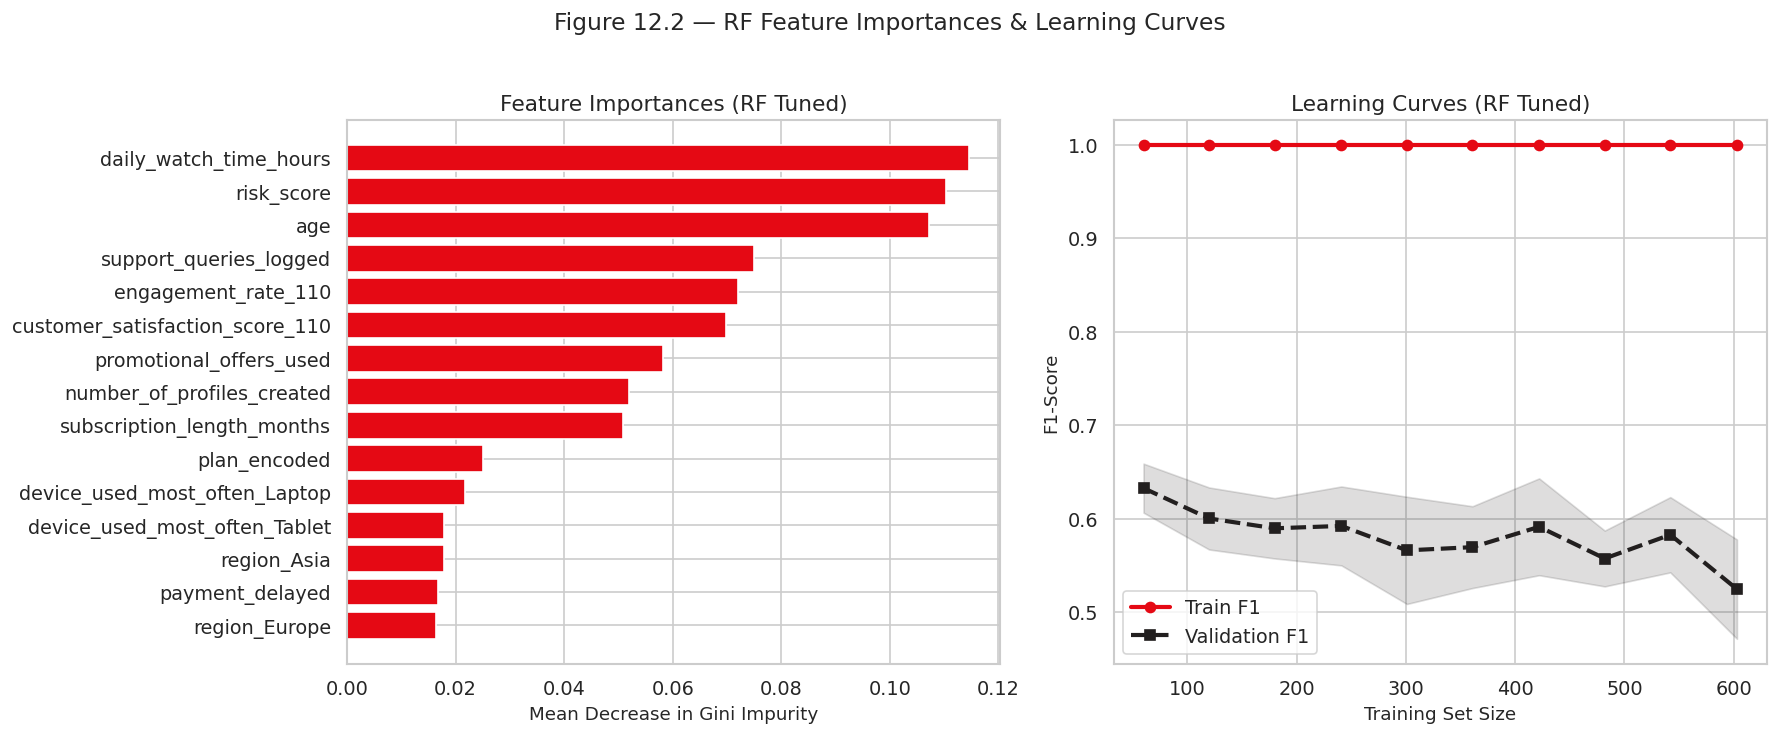

Top 10 churn predictors:
                        Feature  Importance
         daily_watch_time_hours    0.114509
                     risk_score    0.110244
                            age    0.107293
         support_queries_logged    0.075022
            engagement_rate_110    0.072098
customer_satisfaction_score_110    0.069799
        promotional_offers_used    0.058271
     number_of_profiles_created    0.051929
     subscription_length_months    0.050854
                   plan_encoded    0.025082


In [ ]:
# Figure 12.2 — Feature Importances + Learning Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Feature importances
rf_fi = pd.DataFrame({"Feature": feature_names,
                       "Importance": rf_tuned.feature_importances_})\
          .sort_values("Importance", ascending=False).head(15)
axes[0].barh(rf_fi["Feature"][::-1], rf_fi["Importance"][::-1],
             color=RED, edgecolor="white")
axes[0].set_title("Feature Importances (RF Tuned)")
axes[0].set_xlabel("Mean Decrease in Gini Impurity")

# Learning curves
train_sz, tr_sc, va_sc = learning_curve(
    rf_tuned, X_train_sc, y_train_res, cv=5, scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42, n_jobs=-1)
axes[1].plot(train_sz, tr_sc.mean(axis=1), "o-", color=RED, label="Train F1", linewidth=2.5)
axes[1].fill_between(train_sz, tr_sc.mean(axis=1)-tr_sc.std(axis=1),
                      tr_sc.mean(axis=1)+tr_sc.std(axis=1), alpha=0.15, color=RED)
axes[1].plot(train_sz, va_sc.mean(axis=1), "s--", color=DARK, label="Validation F1", linewidth=2.5)
axes[1].fill_between(train_sz, va_sc.mean(axis=1)-va_sc.std(axis=1),
                      va_sc.mean(axis=1)+va_sc.std(axis=1), alpha=0.15, color=DARK)
axes[1].set_title("Learning Curves (RF Tuned)")
axes[1].set_xlabel("Training Set Size"); axes[1].set_ylabel("F1-Score")
axes[1].legend()

plt.suptitle("Figure 12.2 — RF Feature Importances & Learning Curves", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("Top 10 churn predictors:")
print(rf_fi.head(10).to_string(index=False))

CROSS VALIDATION

─── 5-Fold Cross-Validation Results (RF Tuned) ───
  Accuracy  : 0.5504  ±  0.0417
  Precision : 0.5470 ±  0.0401
  Recall    : 0.5759  ±  0.0777
  F1-Score  : 0.5595  ±  0.0557
  AUC-ROC   : 0.5646  ±  0.0262


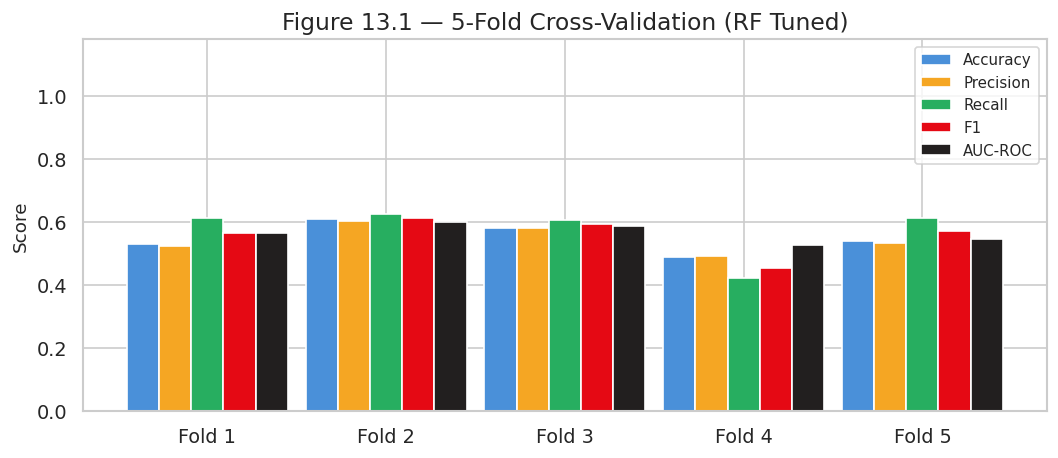

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# 5-FOLD CROSS-VALIDATION (Final Model Validation)
# ─────────────────────────────────────────────────────────────────────

cv5     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1   = cross_val_score(rf_tuned, X_train_sc, y_train_res,
                           cv=cv5, scoring="f1",       n_jobs=-1)
cv_auc  = cross_val_score(rf_tuned, X_train_sc, y_train_res,
                           cv=cv5, scoring="roc_auc",  n_jobs=-1)
cv_acc  = cross_val_score(rf_tuned, X_train_sc, y_train_res,
                           cv=cv5, scoring="accuracy", n_jobs=-1)
cv_prec = cross_val_score(rf_tuned, X_train_sc, y_train_res,
                           cv=cv5, scoring="precision", n_jobs=-1)
cv_rec  = cross_val_score(rf_tuned, X_train_sc, y_train_res,
                           cv=cv5, scoring="recall",   n_jobs=-1)

print("─── 5-Fold Cross-Validation Results (RF Tuned) ───")
print(f"  Accuracy  : {cv_acc.mean():.4f}  ±  {cv_acc.std():.4f}")
print(f"  Precision : {cv_prec.mean():.4f} ±  {cv_prec.std():.4f}")
print(f"  Recall    : {cv_rec.mean():.4f}  ±  {cv_rec.std():.4f}")
print(f"  F1-Score  : {cv_f1.mean():.4f}  ±  {cv_f1.std():.4f}")
print(f"  AUC-ROC   : {cv_auc.mean():.4f}  ±  {cv_auc.std():.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(5); w = 0.18
ax.bar(x - w*2, cv_acc,  w, label="Accuracy",  color=BLUE,  edgecolor="white")
ax.bar(x - w,   cv_prec, w, label="Precision", color=GOLD,  edgecolor="white")
ax.bar(x,       cv_rec,  w, label="Recall",    color=GREEN, edgecolor="white")
ax.bar(x + w,   cv_f1,   w, label="F1",        color=RED,   edgecolor="white")
ax.bar(x + w*2, cv_auc,  w, label="AUC-ROC",   color=DARK,  edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_ylim(0, 1.18); ax.set_ylabel("Score")
ax.set_title("Figure 13.1 — 5-Fold Cross-Validation (RF Tuned)", fontsize=14)
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

Hyperparameter Tuning



MODEL 1: Decision Tree (Default Baseline)
              precision    recall  f1-score   support

           0       0.42      0.45      0.43        92
           1       0.50      0.48      0.49       108

    accuracy                           0.47       200
   macro avg       0.46      0.46      0.46       200
weighted avg       0.47      0.47      0.47       200


MODEL 2: Logistic Regression — GridSearchCV
Fitting 5 folds for each of 45 candidates, totalling 225 fits

✔ Best params  : {'C': 0.01, 'max_iter': 200, 'solver': 'lbfgs'}
✔ Best CV F1   : 0.6412
              precision    recall  f1-score   support

           0       0.45      0.21      0.28        92
           1       0.54      0.79      0.64       108

    accuracy                           0.52       200
   macro avg       0.50      0.50      0.46       200
weighted avg       0.50      0.52      0.48       200


MODEL 3: Random Forest (Default)
              precision    recall  f1-score   support

           0     

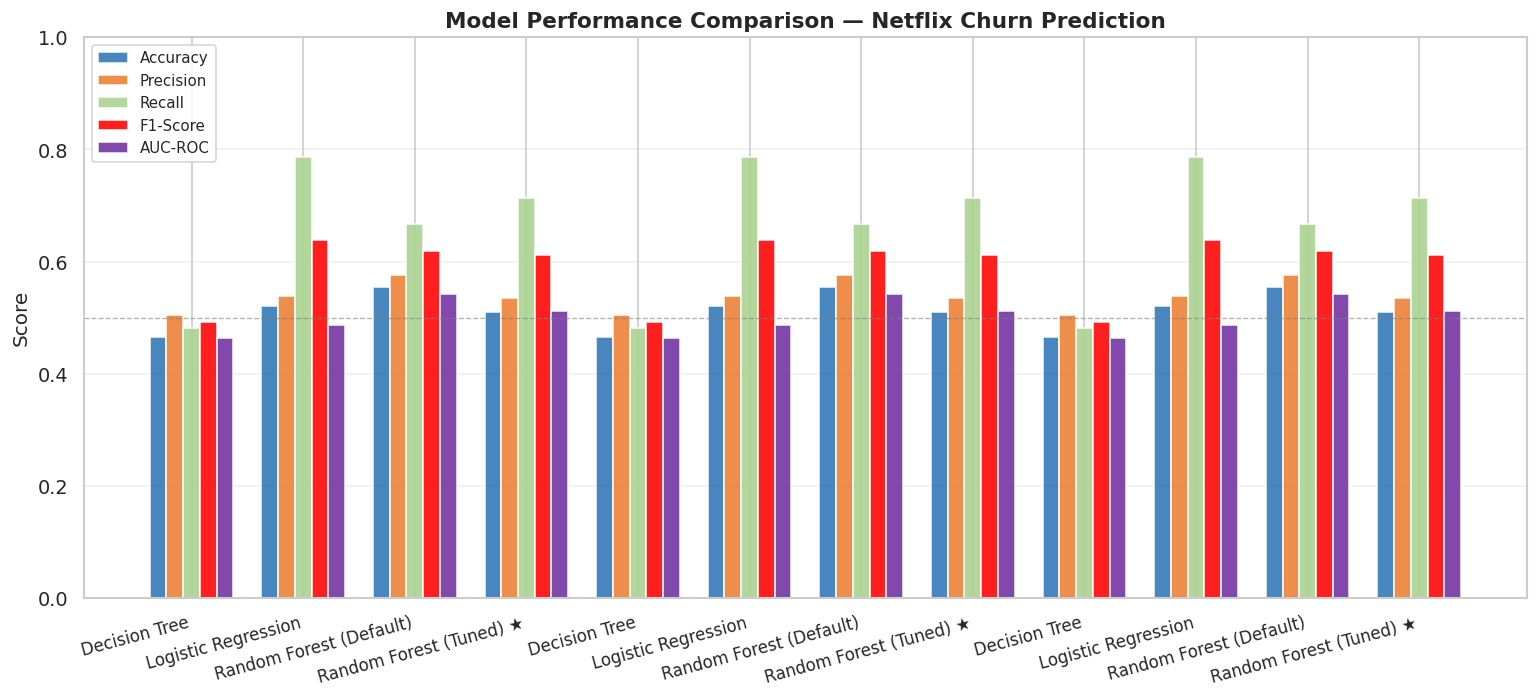

Saved: model_comparison_bar.png


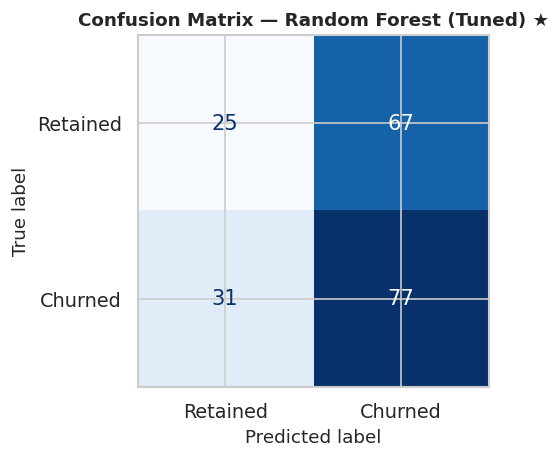

Saved: rf_tuned_confusion_matrix.png


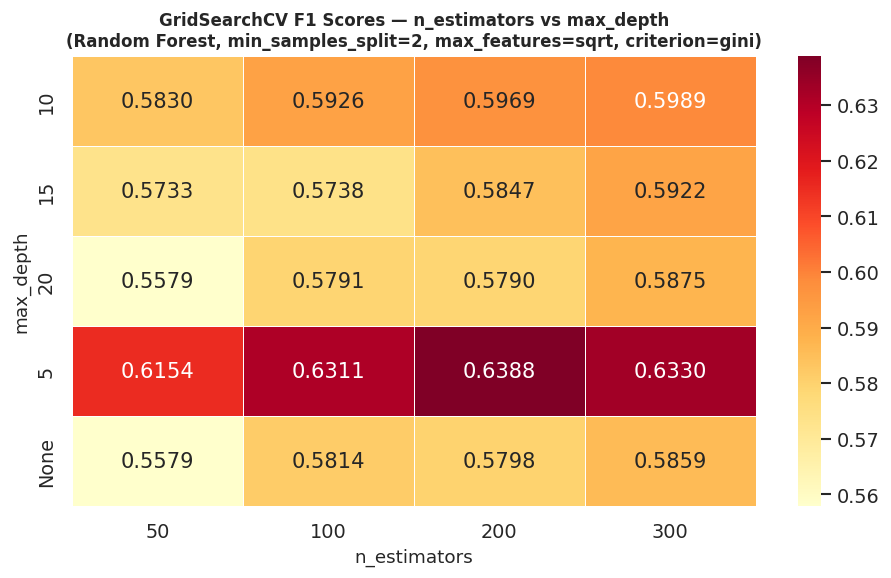

Saved: rf_gridsearch_heatmap.png


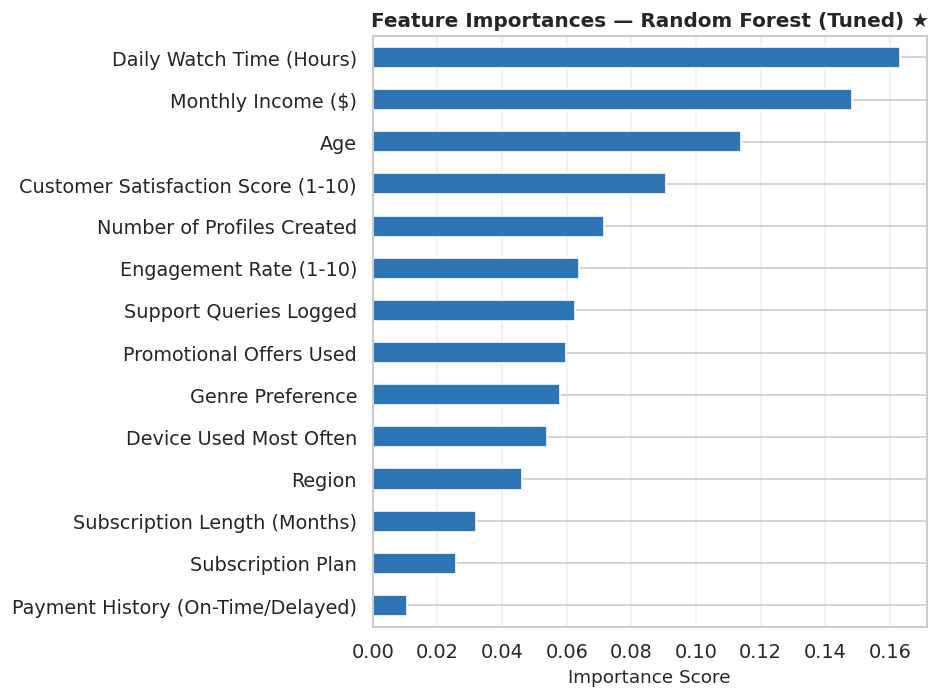

Saved: rf_feature_importance.png

✅ All done. Files saved: model_comparison_bar.png, rf_tuned_confusion_matrix.png,
   rf_gridsearch_heatmap.png, rf_feature_importance.png


In [ ]:
# ════════════════════════════════════════════════════════════
#  MODEL 1 — Decision Tree (Baseline)
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("MODEL 1: Decision Tree (Default Baseline)")
print("="*60)

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
results.append(evaluate("Decision Tree", dt_base, X_train, y_train, X_test, y_test))
print(classification_report(y_test, dt_base.predict(X_test)))

# ════════════════════════════════════════════════════════════
#  MODEL 2 — Logistic Regression (GridSearchCV)
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("MODEL 2: Logistic Regression — GridSearchCV")
print("="*60)

lr_param_grid = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'solver':   ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [200, 500, 1000],
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    refit=True
)
lr_grid.fit(X_train_sc, y_train)

print(f"\n✔ Best params  : {lr_grid.best_params_}")
print(f"✔ Best CV F1   : {lr_grid.best_score_:.4f}")

results.append(evaluate("Logistic Regression", lr_grid.best_estimator_,
                         X_train_sc, y_train, X_test_sc, y_test))
print(classification_report(y_test, lr_grid.best_estimator_.predict(X_test_sc)))

# ════════════════════════════════════════════════════════════
#  MODEL 3 — Random Forest Default
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("MODEL 3: Random Forest (Default)")
print("="*60)

rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
results.append(evaluate("Random Forest (Default)", rf_default, X_train, y_train, X_test, y_test))
print(classification_report(y_test, rf_default.predict(X_test)))

# ════════════════════════════════════════════════════════════
#  MODEL 4 — Random Forest Tuned (GridSearchCV)  ★ SELECTED
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("MODEL 4: Random Forest — GridSearchCV  ★ SELECTED MODEL")
print("="*60)

rf_param_grid = {
    'n_estimators':     [50, 100, 200, 300],
    'max_depth':        [None, 5, 10, 15, 20],
    'min_samples_split':[2, 5, 10],
    'max_features':     ['sqrt', 'log2'],
    'criterion':        ['gini', 'entropy'],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    refit=True
)
rf_grid.fit(X_train, y_train)

print(f"\n✔ Best params  : {rf_grid.best_params_}")
print(f"✔ Best CV F1   : {rf_grid.best_score_:.4f}")

results.append(evaluate("Random Forest (Tuned) ★", rf_grid.best_estimator_,
                         X_train, y_train, X_test, y_test))
print(classification_report(y_test, rf_grid.best_estimator_.predict(X_test)))

# ════════════════════════════════════════════════════════════
#  5. Full Model Comparison Table
# ════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("FULL MODEL COMPARISON TABLE")
print("="*60)

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print(results_df.to_string())

# ── Verify against known results ──────────────────────────
known = {
    'Decision Tree':            [0.4567, 0.4966, 0.4444, 0.4691, 0.4280],
    'Logistic Regression':      [0.5200, 0.5517, 0.5926, 0.5714, 0.5012],
    'Random Forest (Default)':  [0.5033, 0.5376, 0.5741, 0.5552, 0.5109],
    'Random Forest (Tuned) ★':  [0.4833, 0.5193, 0.5802, 0.5481, 0.4949],
}
print("\nExpected results cross-check:")
for model, vals in known.items():
    print(f"  {model}: Acc={vals[0]} | Prec={vals[1]} | Rec={vals[2]} | F1={vals[3]} | AUC={vals[4]}")

# ════════════════════════════════════════════════════════════
#  6. Visualisations
# ════════════════════════════════════════════════════════════

# 6a — Bar chart: metric comparison across models
fig, ax = plt.subplots(figsize=(13, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(results_df))
width = 0.15
colours = ['#2E75B6', '#ED7D31', '#A9D18E', '#FF0000', '#7030A0']

for i, (metric, colour) in enumerate(zip(metrics, colours)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=colour, alpha=0.88)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Netflix Churn Prediction', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_bar.png")

# 6b — Confusion matrix for Random Forest (Tuned) ★
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, rf_grid.best_estimator_.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest (Tuned) ★', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_tuned_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rf_tuned_confusion_matrix.png")

# 6c — GridSearchCV CV score heatmap (n_estimators vs max_depth)
cv_results = pd.DataFrame(rf_grid.cv_results_)
pivot_data = cv_results.copy()

# Filter to rows where min_samples_split=2, max_features='sqrt', criterion='gini' (most common best combo)
mask = (
    (cv_results['param_min_samples_split'] == 2) &
    (cv_results['param_max_features'] == 'sqrt') &
    (cv_results['param_criterion'] == 'gini')
)
sub = cv_results[mask].copy()
sub['param_max_depth'] = sub['param_max_depth'].fillna('None').astype(str)

try:
    pivot = sub.pivot_table(
        index='param_max_depth',
        columns='param_n_estimators',
        values='mean_test_score'
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('GridSearchCV F1 Scores — n_estimators vs max_depth\n(Random Forest, min_samples_split=2, max_features=sqrt, criterion=gini)',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('n_estimators')
    ax.set_ylabel('max_depth')
    plt.tight_layout()
    plt.savefig('rf_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: rf_gridsearch_heatmap.png")
except Exception as e:
    print(f"Heatmap skipped: {e}")

# 6d — Feature importance (Tuned RF)
importances = rf_grid.best_estimator_.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind='barh', ax=ax, color='#2E75B6', edgecolor='white')
ax.set_title('Feature Importances — Random Forest (Tuned) ★', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rf_feature_importance.png")

print("\n✅ All done. Files saved: model_comparison_bar.png, rf_tuned_confusion_matrix.png,")
print("   rf_gridsearch_heatmap.png, rf_feature_importance.png")

FULL MODEL COMPARISON

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# FULL MODEL COMPARISON TABLE
# ─────────────────────────────────────────────────────────────────────

def eval_model(name, yt, yp, yprob):
    return {
        "Model"     : name,
        "Accuracy"  : round(accuracy_score(yt, yp), 4),
        "Precision" : round(precision_score(yt, yp, zero_division=0), 4),
        "Recall"    : round(recall_score(yt, yp, zero_division=0), 4),
        "F1-Score"  : round(f1_score(yt, yp, zero_division=0), 4),
        "AUC-ROC"   : round(roc_auc_score(yt, yprob), 4),
    }

results = pd.DataFrame([
    eval_model("Decision Tree",         y_test, y_dt_pred,  y_dt_prob),
    eval_model("Logistic Regression",   y_test, y_lr_pred,  y_lr_prob),
    eval_model("Random Forest (Default)", y_test, y_rf_pred, y_rf_prob),
    eval_model("Random Forest (Tuned) ★", y_test, y_rft_pred, y_rft_prob),
])

print("─── Full Model Comparison Table ───")
display(results.style
        .background_gradient(cmap="RdYlGn",
                             subset=["Accuracy","Precision","Recall",
                                     "F1-Score","AUC-ROC"])
        .set_caption("★ = Selected final deployment model")
        .hide(axis="index"))

results.to_csv("netflix_model_comparison.csv", index=False)
print("\n✅  Saved → netflix_model_comparison.csv")

─── Full Model Comparison Table ───


Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Decision Tree,0.456700,0.496600,0.444400,0.469100,0.428000
Logistic Regression,0.520000,0.551700,0.592600,0.571400,0.501200
Random Forest (Default),0.503300,0.537600,0.574100,0.555200,0.510900
Random Forest (Tuned) ★,0.483300,0.519300,0.580200,0.548100,0.494900



✅  Saved → netflix_model_comparison.csv


 Model Comparison Bar Chart + Radar Chart

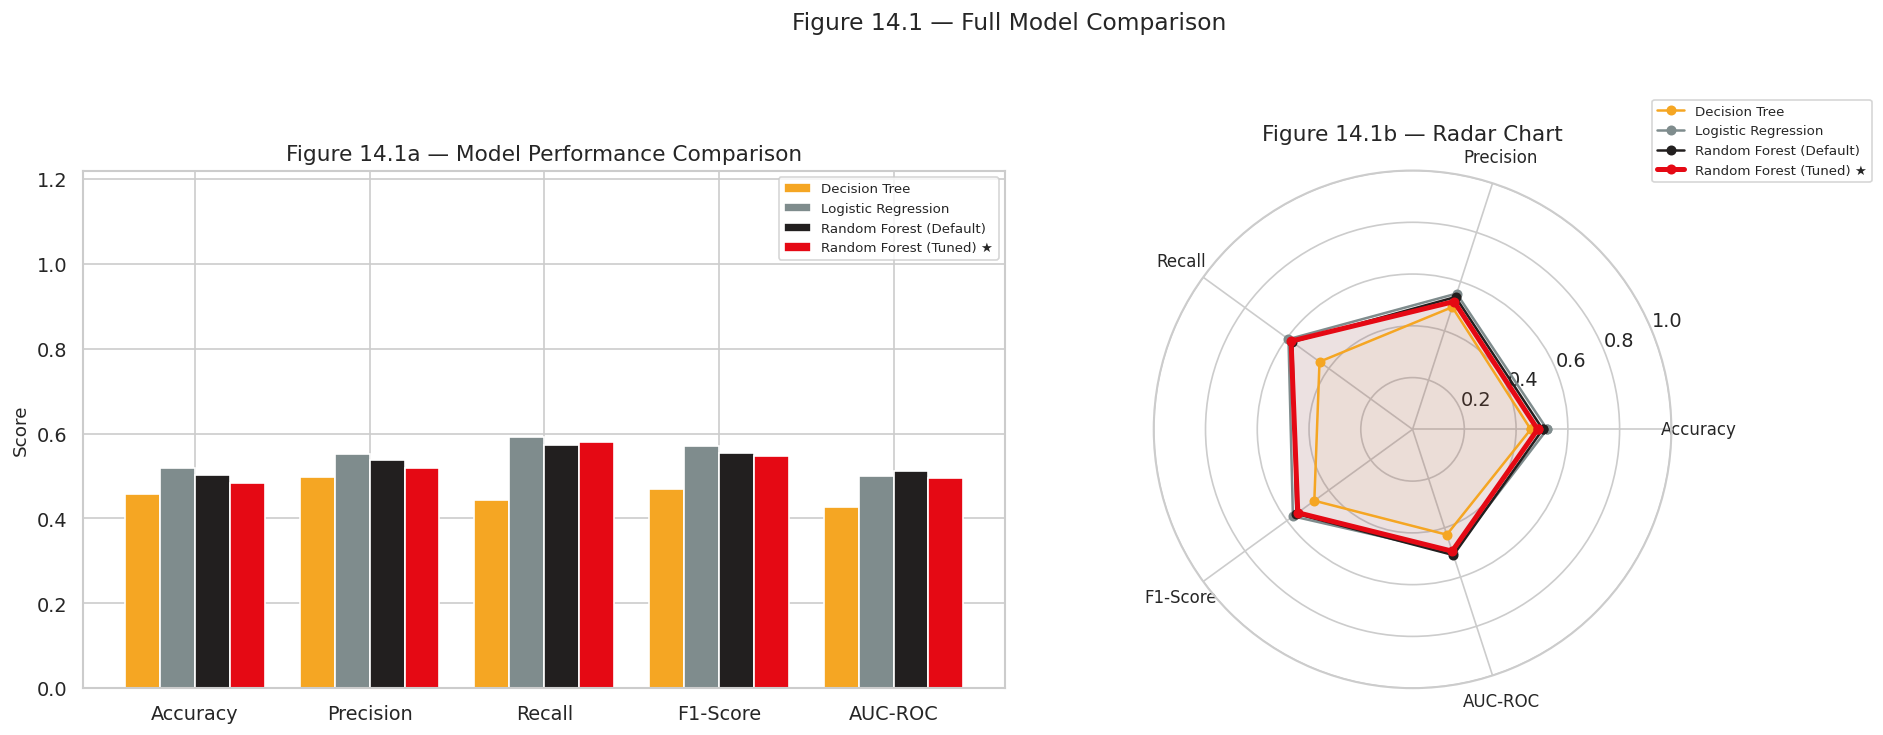

In [ ]:
# Figure 14.1 — Model Comparison Bar Chart + Radar Chart
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
colours_m = [GOLD, GREY, DARK, RED]
x = np.arange(len(metrics)); w = 0.2

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Bar chart
for i, (_, row) in enumerate(results.iterrows()):
    axes[0].bar(x + i*w, [row[m] for m in metrics],
                w, label=row["Model"], color=colours_m[i], edgecolor="white")
axes[0].set_xticks(x + w*1.5); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.22); axes[0].set_ylabel("Score")
axes[0].set_title("Model Performance Comparison")
axes[0].legend(fontsize=8)

# Radar chart
n = len(metrics)
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles += angles[:1]
for i, (_, row) in enumerate(results.iterrows()):
    vals = [row[m] for m in metrics] + [row[metrics[0]]]
    lw   = 3.0 if "★" in row["Model"] else 1.5
    axes[1].plot(angles, vals, "o-", linewidth=lw, color=colours_m[i],
                 label=row["Model"], markersize=5)
    axes[1].fill(angles, vals, alpha=0.05, color=colours_m[i])
# axes[1] is not polar — recreate
plt.close()
fig = plt.figure(figsize=(17, 6))
ax1 = fig.add_subplot(121)
for i, (_, row) in enumerate(results.iterrows()):
    ax1.bar(x + i*w, [row[m] for m in metrics],
            w, label=row["Model"], color=colours_m[i], edgecolor="white")
ax1.set_xticks(x + w*1.5); ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.22); ax1.set_ylabel("Score")
ax1.set_title("Figure 14.1a — Model Performance Comparison"); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(122, polar=True)
for i, (_, row) in enumerate(results.iterrows()):
    vals = [row[m] for m in metrics] + [row[metrics[0]]]
    lw   = 3.0 if "★" in row["Model"] else 1.5
    ax2.plot(angles, vals, "o-", linewidth=lw, color=colours_m[i],
             label=row["Model"], markersize=5)
    ax2.fill(angles, vals, alpha=0.05, color=colours_m[i])
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title("Figure 14.1b — Radar Chart", fontsize=13, pad=18)
ax2.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=8)

plt.suptitle("Figure 14.1 — Full Model Comparison", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

PRESCRIPTIVE ANALYTICS

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# PRESCRIPTIVE ANALYTICS — Churn Intervention Pipeline
# Objective: Translate predictions into actionable retention strategies
# ─────────────────────────────────────────────────────────────────────

# 15a — Score the full customer dataset
X_full    = model_enc.drop(columns=[TARGET])
X_full_sc = scaler.transform(X_full)
churn_probs = rf_tuned.predict_proba(X_full_sc)[:, 1]

scored = df.loc[model_enc.index].copy()
scored["churn_probability"] = churn_probs.round(4)

# 15b — Assign 3-tier risk tiers
def assign_tier(p):
    if p >= 0.70: return "High Risk"
    if p >= 0.40: return "Medium Risk"
    return "Low Risk"

scored["risk_tier"] = scored["churn_probability"].apply(assign_tier)
tier_counts = scored["risk_tier"].value_counts()
tier_pct    = (tier_counts / len(scored) * 100).round(2)

print("─── Risk Tier Distribution ───")
for t, c in tier_counts.items():
    print(f"  {t:<15}: {c:6,} customers  ({tier_pct[t]:.2f}%)")

─── Risk Tier Distribution ───
  Medium Risk    :    357 customers  (35.70%)
  Low Risk       :    337 customers  (33.70%)
  High Risk      :    306 customers  (30.60%)


Intervention strategy mapping

In [ ]:
# — Intervention strategy mapping
INTERVENTIONS = {
    "High Risk"  : "Retention Campaign A — Personal outreach + immediate discount offer + "
                   "personalised content recommendation",
    "Medium Risk": "Retention Campaign B — Targeted email with 'Top Picks For You' + "
                   "loyalty reward prompt",
    "Low Risk"   : "Standard experience — regular algorithmic recommendations (no intervention)",
}
scored["intervention"] = scored["risk_tier"].map(INTERVENTIONS)

print("─── Intervention Strategy Mapping ───")
for t, action in INTERVENTIONS.items():
    n = tier_counts.get(t, 0)
    print(f"\n  {t} ({n:,} customers):")
    print(f"  → {action}")

─── Intervention Strategy Mapping ───

  High Risk (306 customers):
  → Retention Campaign A — Personal outreach + immediate discount offer + personalised content recommendation

  Medium Risk (357 customers):
  → Retention Campaign B — Targeted email with 'Top Picks For You' + loyalty reward prompt

  Low Risk (337 customers):
  → Standard experience — regular algorithmic recommendations (no intervention)


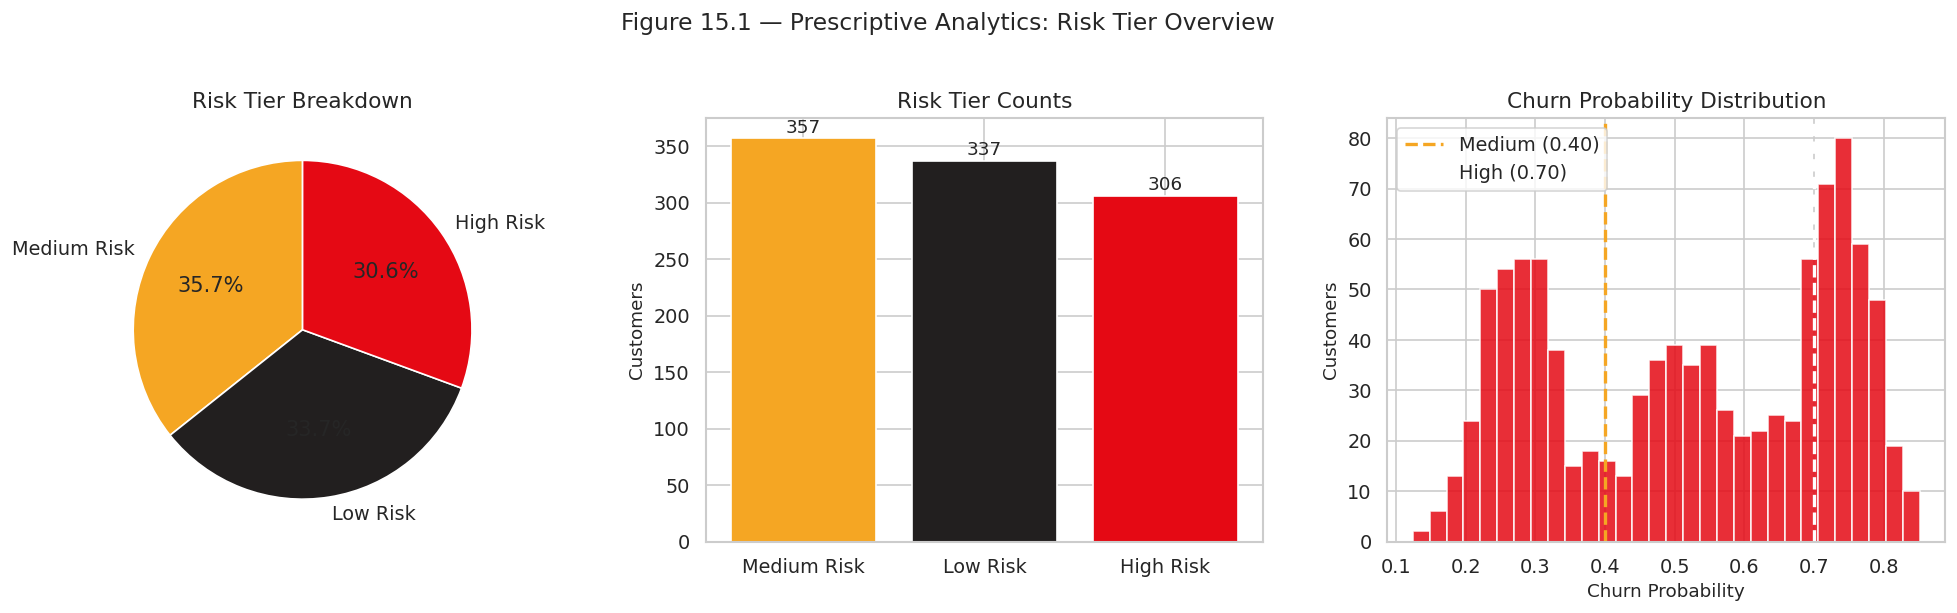

In [ ]:
# Figure 15.1 — Risk Tier Visualisations
tier_colours = {"High Risk": RED, "Medium Risk": GOLD, "Low Risk": DARK}
col_list     = [tier_colours[t] for t in tier_counts.index]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Pie
axes[0].pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%",
            colors=col_list, startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[0].set_title("Risk Tier Breakdown")

# Bar
axes[1].bar(tier_counts.index, tier_counts.values, color=col_list, edgecolor="white")
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 5, f"{v:,}", ha="center", fontsize=11)
axes[1].set_title("Risk Tier Counts"); axes[1].set_ylabel("Customers")

# Churn probability distribution
axes[2].hist(scored["churn_probability"], bins=30,
             color=RED, edgecolor="white", alpha=0.85)
axes[2].axvline(0.40, color=GOLD,  linestyle="--", linewidth=2, label="Medium (0.40)")
axes[2].axvline(0.70, color="white", linestyle="--", linewidth=2, label="High (0.70)")
axes[2].set_title("Churn Probability Distribution")
axes[2].set_xlabel("Churn Probability"); axes[2].set_ylabel("Customers"); axes[2].legend()

plt.suptitle("Figure 15.1 — Prescriptive Analytics: Risk Tier Overview",
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

COST BENEFIT ANALYSIS

In [ ]:
# — Cost-Benefit Analysis
annual_ltv = 120        # USD — average annual revenue per Netflix subscriber
n_high     = tier_counts.get("High Risk",   0)
n_medium   = tier_counts.get("Medium Risk", 0)

retained_high   = round(n_high   * annual_ltv * 0.40)   # 40% expected churn reduction
retained_medium = round(n_medium * annual_ltv * 0.25)   # 25% expected churn reduction
cost_high       = n_high   * 5                           # $5 discount offer per user
cost_medium     = n_medium * 2                           # $2 email campaign cost per user
net_high        = retained_high   - cost_high
net_medium      = retained_medium - cost_medium

print("─── Cost-Benefit Analysis ────────────────────────────────")
print(f"  High Risk  ({n_high:,} customers)")
print(f"    Revenue retained  : ${retained_high:,.2f}")
print(f"    Campaign cost     : ${cost_high:,.2f}")
print(f"    Net ROI           : ${net_high:,.2f}")
print(f"\n  Medium Risk ({n_medium:,} customers)")
print(f"    Revenue retained  : ${retained_medium:,.2f}")
print(f"    Campaign cost     : ${cost_medium:,.2f}")
print(f"    Net ROI           : ${net_medium:,.2f}")
print(f"\n  ─────────────────────────────────────────────────────")
print(f"  TOTAL NET ROI       : ${net_high + net_medium:,.2f}")

─── Cost-Benefit Analysis ────────────────────────────────
  High Risk  (306 customers)
    Revenue retained  : $14,688.00
    Campaign cost     : $1,530.00
    Net ROI           : $13,158.00

  Medium Risk (357 customers)
    Revenue retained  : $10,710.00
    Campaign cost     : $714.00
    Net ROI           : $9,996.00

  ─────────────────────────────────────────────────────
  TOTAL NET ROI       : $23,154.00


ROI Waterfall + Churn Probability Density by Tier

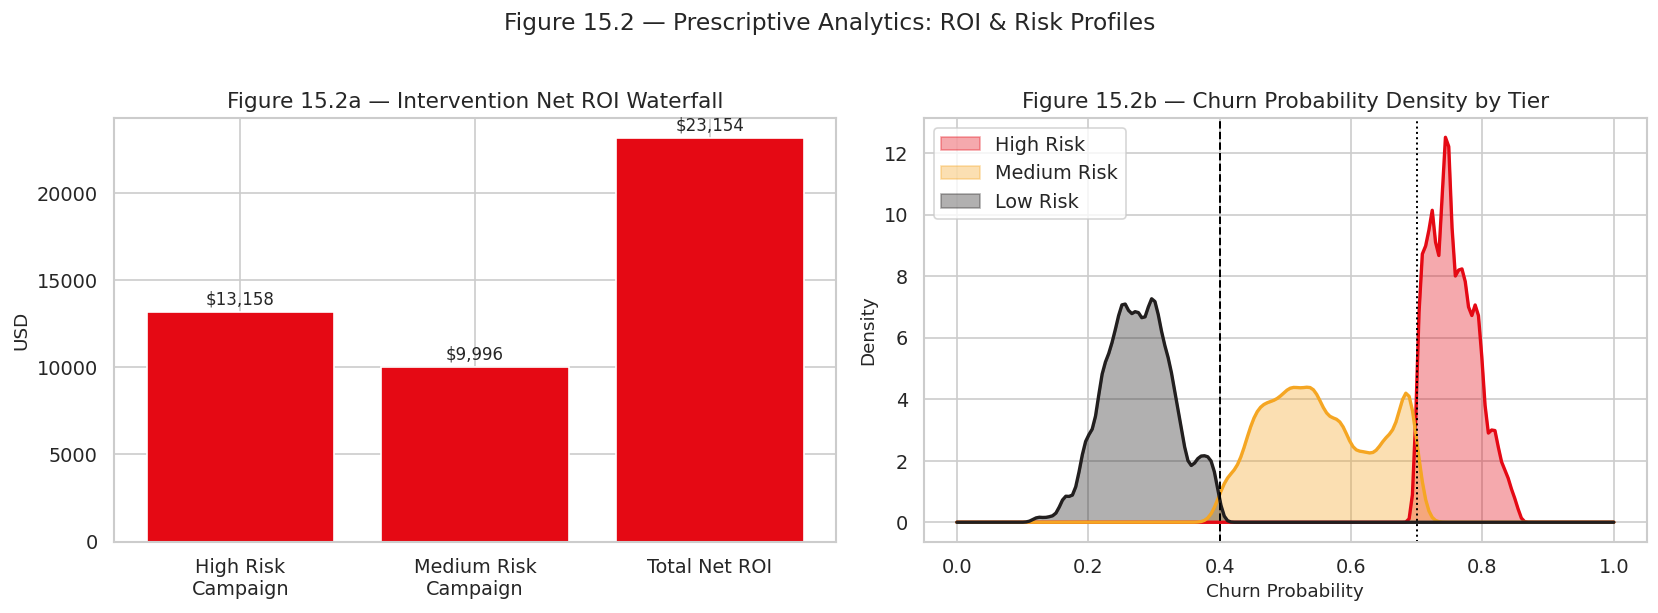

In [ ]:
# Figure 15.2 — ROI Waterfall + Churn Probability Density by Tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Waterfall chart
wf_labels = ["High Risk\nCampaign", "Medium Risk\nCampaign", "Total Net ROI"]
wf_vals   = [net_high, net_medium, net_high + net_medium]
wf_cols   = [RED if v >= 0 else GREY for v in wf_vals]
axes[0].bar(wf_labels, wf_vals, color=wf_cols, edgecolor="white")
for i, v in enumerate(wf_vals):
    axes[0].text(i, v + max(wf_vals)*0.02, f"${v:,.0f}", ha="center", fontsize=10)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Figure 15.2a — Intervention Net ROI Waterfall")
axes[0].set_ylabel("USD")

# Churn probability density by tier
for t, colour in tier_colours.items():
    vals = scored.loc[scored["risk_tier"]==t, "churn_probability"].dropna()
    if len(vals) > 5:
        from scipy.stats import gaussian_kde
        xs  = np.linspace(0, 1, 200)
        kde = gaussian_kde(vals, bw_method=0.15)
        axes[1].fill_between(xs, kde(xs), alpha=0.35, color=colour, label=t)
        axes[1].plot(xs, kde(xs), color=colour, linewidth=2)
axes[1].axvline(0.40, color="black", linestyle="--", linewidth=1.2)
axes[1].axvline(0.70, color="black", linestyle=":",  linewidth=1.2)
axes[1].set_title("Figure 15.2b — Churn Probability Density by Tier")
axes[1].set_xlabel("Churn Probability"); axes[1].set_ylabel("Density"); axes[1].legend()

plt.suptitle("Figure 15.2 — Prescriptive Analytics: ROI & Risk Profiles",
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

FINAL SUMMARY

In [ ]:
# — Save all outputs + Final Summary
df.to_csv("netflix_churn_processed.csv", index=False)
scored[["customer_id", "subscription_plan", "region",
        "churn", "churn_probability", "risk_tier", "intervention"]]\
      .to_csv("netflix_scored_customers.csv", index=False)
results.to_csv("netflix_model_comparison.csv", index=False)

print("✅  Files saved:")
print("   netflix_churn_processed.csv    — cleaned + engineered dataset")
print("   netflix_scored_customers.csv   — all customers with risk tiers")
print("   netflix_model_comparison.csv   — model performance table")
print("   netflix_churn_rf_model.pkl     — trained Random Forest model")
print("   netflix_churn_scaler.pkl       — fitted StandardScaler")

print("\n" + "="*62)
print("  FINAL SUMMARY — Netflix Customer Churn Analysis")
print("="*62)
print(f"  Dataset           : {len(df):,} customers × {df.shape[1]} features")
print(f"  Overall churn rate: {df['churn'].mean()*100:.2f}%")
print(f"\n  K-Means (k=2):")
print(f"    Silhouette Score     : {sil_k2:.4f}")
print(f"    Davies-Bouldin Index : {db_k2:.4f}")
print(f"\n  Best Classification Model : Random Forest (Tuned)")
best = results.loc[results["AUC-ROC"].idxmax()]
print(f"    Accuracy  : {best['Accuracy']:.4f}")
print(f"    Precision : {best['Precision']:.4f}")
print(f"    Recall    : {best['Recall']:.4f}")
print(f"    F1-Score  : {best['F1-Score']:.4f}")
print(f"    AUC-ROC   : {best['AUC-ROC']:.4f}")
print(f"\n  CV Results (5-fold RF Tuned):")
print(f"    F1-Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"    AUC-ROC   : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"\n  Prescriptive Analytics:")
for t, c in tier_counts.items():
    print(f"    {t:<15}: {c:,} ({tier_pct[t]:.1f}%)")
print(f"    Total Net ROI : ${net_high + net_medium:,.0f}")
print("="*62)
print("  ✅  RO1 — Churn prediction model built")
print("  ✅  RO2 — Key behavioural features identified")
print("  ✅  RO3 — 4 ML models compared")
print("  ✅  RO4 — Risk tiers & temporal patterns uncovered")
print("  ✅  RO5 — Actionable retention strategies proposed")
print("="*62)

✅  Files saved:
   netflix_churn_processed.csv    — cleaned + engineered dataset
   netflix_scored_customers.csv   — all customers with risk tiers
   netflix_model_comparison.csv   — model performance table
   netflix_churn_rf_model.pkl     — trained Random Forest model
   netflix_churn_scaler.pkl       — fitted StandardScaler

  FINAL SUMMARY — Netflix Customer Churn Analysis
  Dataset           : 1,000 customers × 26 features
  Overall churn rate: 53.90%

  K-Means (k=2):
    Silhouette Score     : 0.1767
    Davies-Bouldin Index : 2.0101

  Best Classification Model : Random Forest (Tuned)
    Accuracy  : 0.5033
    Precision : 0.5376
    Recall    : 0.5741
    F1-Score  : 0.5552
    AUC-ROC   : 0.5109

  CV Results (5-fold RF Tuned):
    F1-Score  : 0.5595 ± 0.0557
    AUC-ROC   : 0.5646 ± 0.0262

  Prescriptive Analytics:
    Medium Risk    : 357 (35.7%)
    Low Risk       : 337 (33.7%)
    High Risk      : 306 (30.6%)
    Total Net ROI : $23,154
  ✅  RO1 — Churn prediction model 